# Лабораторная работа №3  
## Классификация временных рядов и прогнозирование метеоданных шести городов России

В данном notebook реализован полный двухэтапный пайплайн:

1. **EDA и проверка качества данных**
2. **Инжиниринг признаков**
3. **Классификация климатического типа по окну временного ряда**
4. **Прогнозирование температуры на 30 дней вперёд для каждого города**
5. **Интеграция в единый two-stage pipeline**
6. **Итоговая интерпретация результатов**

> Согласно поставленному заданию - исходные сведения приводятся к **дневной частоте** для этапа прогнозирования,  
> в то время как классификация строится по **скользящим окнам** с агрегированными статистиками.

## 0. Практические допущения

#### Причины для ресемплирования исходных сведений в daily
Исходные сведения являются почасовыми. Для прогноза на месяц вперёд более удобным и разусным решением будет перейти к дневной частоте так как:
- уменьшается шум внутрисуточных колебаний;
- горизонт `H=30` естественно интерпретируется как **30 дней**;
- признаки становятся более устойчивыми для моделей машинного обучения.

#### Климатические классы
В задании сказано, что для каждого типа климата представлено не менее двух городов.  
Ниже применяется рабочая группировка:

- **умеренно-континентальный**: Москва, Санкт-Петербург
- **морской субтропический**: Сочи, Геленджик
- **дальневосточный**: Благовещенск, Находка

Это прикладная группировка для задачи автоматического диспетчеризации моделей.  
Она не претендует на строгое академическое климатологическое деление, но хорошо подходит для ML-пайплайна.

In [ ]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_white

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## 1. Загрузка данных

In [ ]:
CLIMATE_MAP = {
    "Москва": "умеренно-континентальный",
    "Санкт-Петербург": "умеренно-континентальный",
    "Сочи": "морской субтропический",
    "Геленджик": "морской субтропический",
    "Благовещенск": "дальневосточный",
    "Находка": "дальневосточный",
}

BASE_FEATURES = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "weathercode",
    "wind_speed_10m",
    "surface_pressure",
]

DAILY_AGG = {
    "temperature_2m": "mean",
    "relative_humidity_2m": "mean",
    "precipitation": "sum",
    "rain": "sum",
    "snowfall": "sum",
    "weathercode": "median",
    "wind_speed_10m": "mean",
    "surface_pressure": "mean",
}


def load_weather_data(data_dir: str | Path) -> pd.DataFrame:
    data_dir = Path(data_dir)
    frames = []
    for path in sorted(data_dir.glob("*.parquet")):
        city = path.name.split("_")[0]
        table = pq.read_table(path)
        df = table.to_pandas()
        if "time" in df.columns:
            df["time"] = pd.to_datetime(df["time"])
            df = df.set_index("time").sort_index()
        df["city"] = city
        frames.append(df)

    if not frames:
        raise ValueError(f"В {data_dir} не найдено parquet-файлов")

    full = pd.concat(frames).sort_index()
    full["climate_type"] = full["city"].map(CLIMATE_MAP)
    return full


DATA_DIR = 'data'
raw_df = load_weather_data(DATA_DIR)
print(f"DATA_DIR = {DATA_DIR}")
print(raw_df.shape)
display(raw_df.head())

DATA_DIR = data
(368208, 10)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,city,climate_type
time,,,,,,,,,,
2019-01-01,-13.7,56,0.0,0.0,0.0,3,12.6,1008.700012,Благовещенск,дальневосточный
2019-01-01,-6.5,92,0.0,0.0,0.0,3,10.8,1000.500000,Москва,умеренно-континентальный
2019-01-01,-13.4,58,0.0,0.0,0.0,0,5.2,1025.500000,Находка,дальневосточный
2019-01-01,-1.8,85,0.0,0.0,0.0,3,23.5,1015.200012,Санкт-Петербург,умеренно-континентальный
2019-01-01,4.6,89,0.2,0.2,0.0,51,8.0,1024.699951,Сочи,морской субтропический


In [ ]:
summary_df = (
    raw_df.reset_index()
    .groupby("city")
    .agg(
        start=("time", "min"),
        end=("time", "max"),
        rows=("time", "size"),
        missing_total=("temperature_2m", lambda s: 0),
    )
)

missing_by_city = raw_df.groupby("city")[BASE_FEATURES].apply(lambda x: x.isna().sum().sum())
summary_df["missing_total"] = missing_by_city
display(summary_df)

,start,end,rows,missing_total
city,,,,
Благовещенск,2019-01-01,2025-12-31 23:00:00,61368,0
Геленджик,2019-01-01,2025-12-31 23:00:00,61368,0
Москва,2019-01-01,2025-12-31 23:00:00,61368,0
Находка,2019-01-01,2025-12-31 23:00:00,61368,0
Санкт-Петербург,2019-01-01,2025-12-31 23:00:00,61368,0
Сочи,2019-01-01,2025-12-31 23:00:00,61368,0


#### Выводы по загрузке исходных сведений
- исходные сведения успешно загружены для 6 городов;
- покрытие: 2019–2025 годы;
- частота исходных данных — **почасовая**;
- пропуски далее проверяются явно, но в данном наборе они чаще всего отсутствуют или близки к нулю.

## 2. Ресемплинг и первичная подготовка

In [ ]:
daily_df = (
    raw_df.groupby("city")
    .resample("D")
    .agg(DAILY_AGG)
    .reset_index()
    .sort_values(["city", "time"])
)

daily_df["climate_type"] = daily_df["city"].map(CLIMATE_MAP)

print(daily_df.shape)
display(daily_df.head())

(15342, 11)


,city,time,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,climate_type
0,Благовещенск,2019-01-01,-14.037499,63.083333,0.0,0.0,0.0,0.0,13.400001,1008.362488,дальневосточный
1,Благовещенск,2019-01-02,-18.391666,72.875000,0.0,0.0,0.0,0.0,10.904167,1010.916687,дальневосточный
2,Благовещенск,2019-01-03,-18.770834,70.041667,0.0,0.0,0.0,0.0,8.770833,1010.370850,дальневосточный
3,Благовещенск,2019-01-04,-20.787500,75.166667,0.0,0.0,0.0,3.0,8.083333,1004.587463,дальневосточный
4,Благовещенск,2019-01-05,-19.866667,72.333333,0.0,0.0,0.0,0.0,10.708333,1007.562500,дальневосточный


In [ ]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    dt = pd.to_datetime(out["time"])
    out["hour"] = getattr(dt.dt, "hour", 0)
    out["dayofweek"] = dt.dt.dayofweek
    out["day"] = dt.dt.day
    out["month"] = dt.dt.month
    out["quarter"] = dt.dt.quarter
    out["year"] = dt.dt.year
    out["dayofyear"] = dt.dt.dayofyear

    out["season"] = np.select(
        [
            out["month"].isin([12, 1, 2]),
            out["month"].isin([3, 4, 5]),
            out["month"].isin([6, 7, 8]),
            out["month"].isin([9, 10, 11]),
        ],
        ["winter", "spring", "summer", "autumn"],
        default="unknown",
    )

    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["doy_sin"] = np.sin(2 * np.pi * out["dayofyear"] / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * out["dayofyear"] / 365.25)
    return out


daily_df = add_time_features(daily_df)
display(daily_df.head())

,city,time,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,...,quarter,year,dayofyear,season,month_sin,month_cos,hour_sin,hour_cos,doy_sin,doy_cos
0,Благовещенск,2019-01-01,-14.037499,63.083333,0.0,0.0,0.0,0.0,13.400001,1008.362488,...,1,2019,1,winter,0.5,0.866025,0.0,1.0,0.017202,0.999852
1,Благовещенск,2019-01-02,-18.391666,72.875000,0.0,0.0,0.0,0.0,10.904167,1010.916687,...,1,2019,2,winter,0.5,0.866025,0.0,1.0,0.034398,0.999408
2,Благовещенск,2019-01-03,-18.770834,70.041667,0.0,0.0,0.0,0.0,8.770833,1010.370850,...,1,2019,3,winter,0.5,0.866025,0.0,1.0,0.051584,0.998669
3,Благовещенск,2019-01-04,-20.787500,75.166667,0.0,0.0,0.0,3.0,8.083333,1004.587463,...,1,2019,4,winter,0.5,0.866025,0.0,1.0,0.068755,0.997634
4,Благовещенск,2019-01-05,-19.866667,72.333333,0.0,0.0,0.0,0.0,10.708333,1007.562500,...,1,2019,5,winter,0.5,0.866025,0.0,1.0,0.085906,0.996303


#### Причины для ресемплинга
Для месячного прогноза daily-частота лучше отражает медленные атмосферные процессы, в отличие от почасовых значений.  
Кроме того, при daily-агрегации:
- температура и влажность усредняются;
- осадки, дождь и снег накапливаются суммой;
- давление и ветер усредняются;
- погодный код остаётся как медиана/типичный уровень.

## 3. EDA — разведочный исследование данных

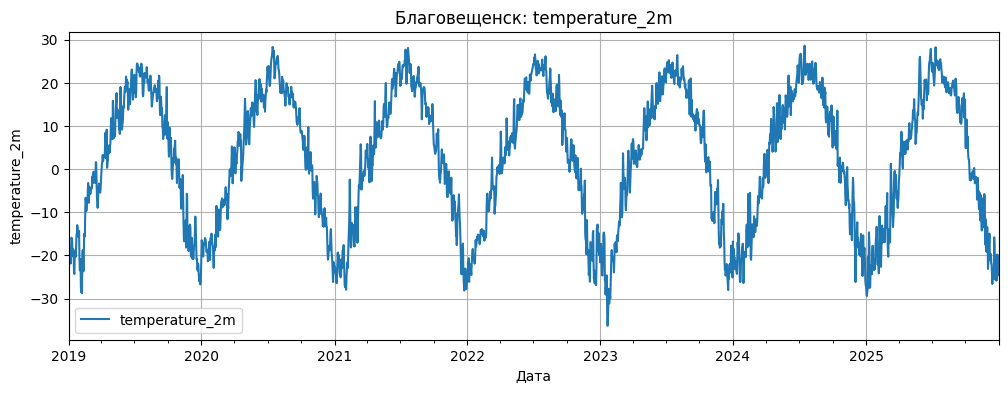

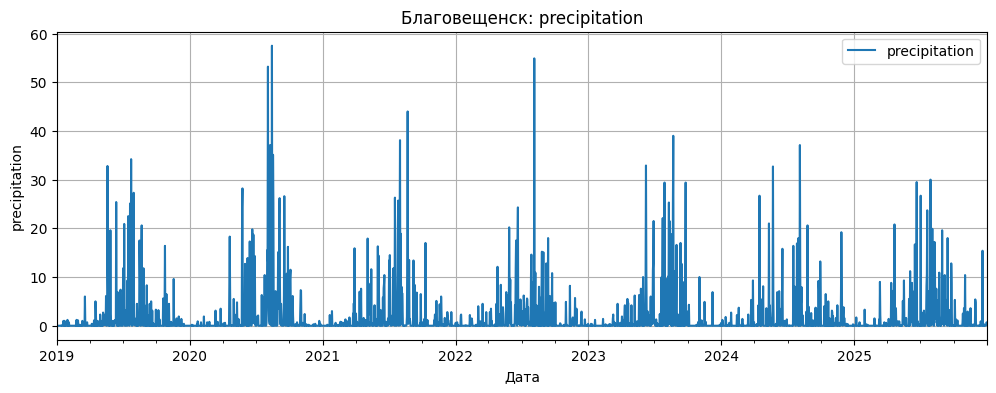

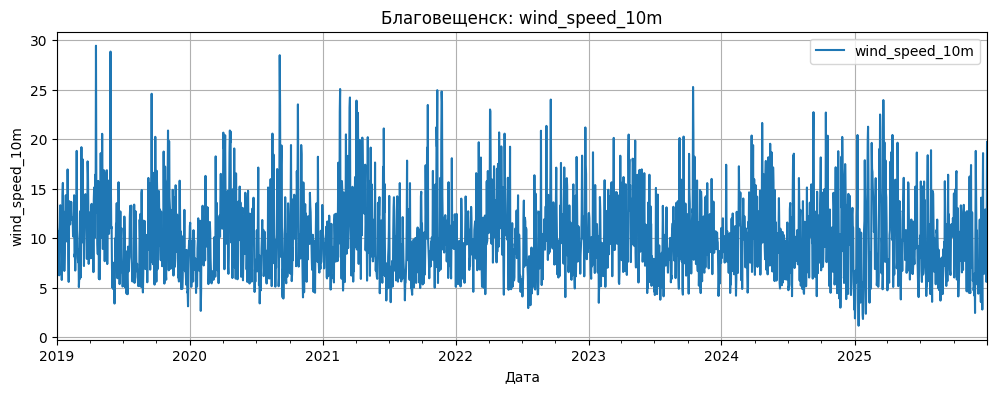

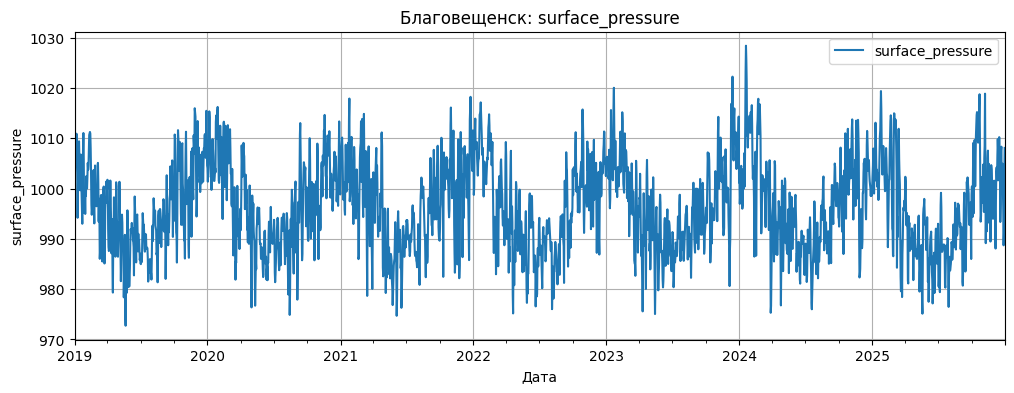

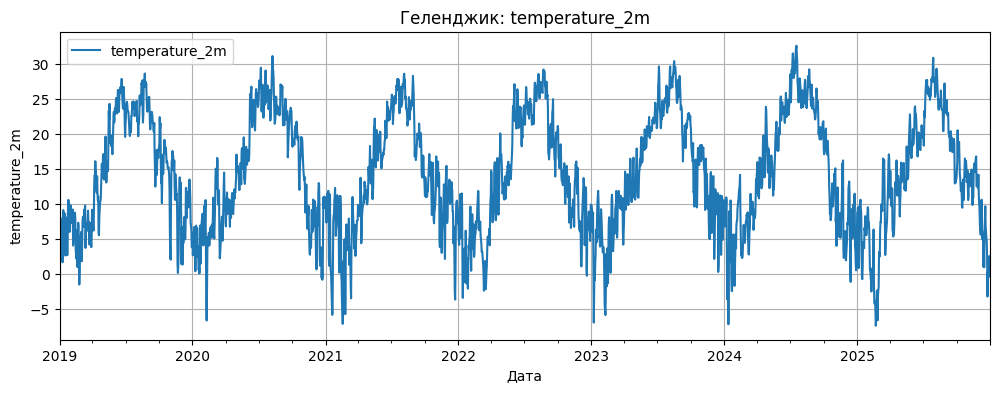

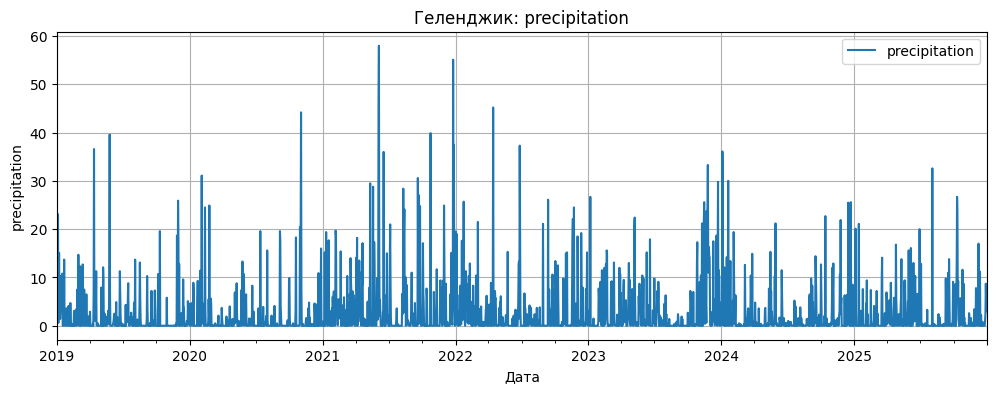

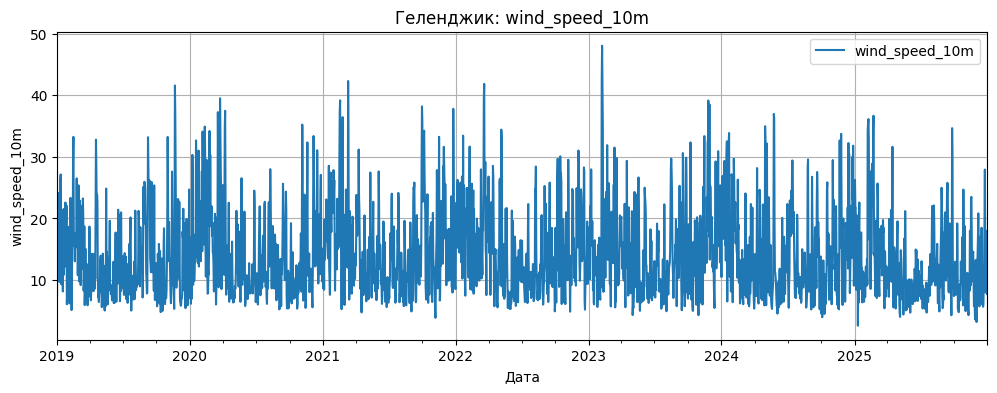

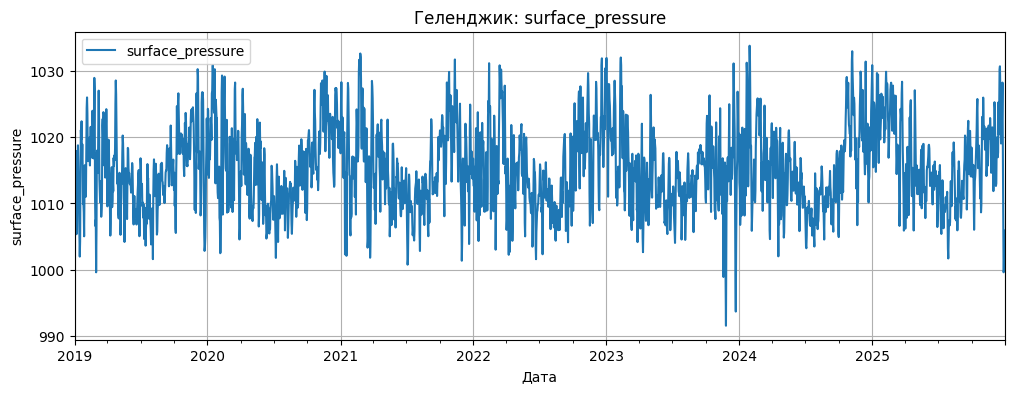

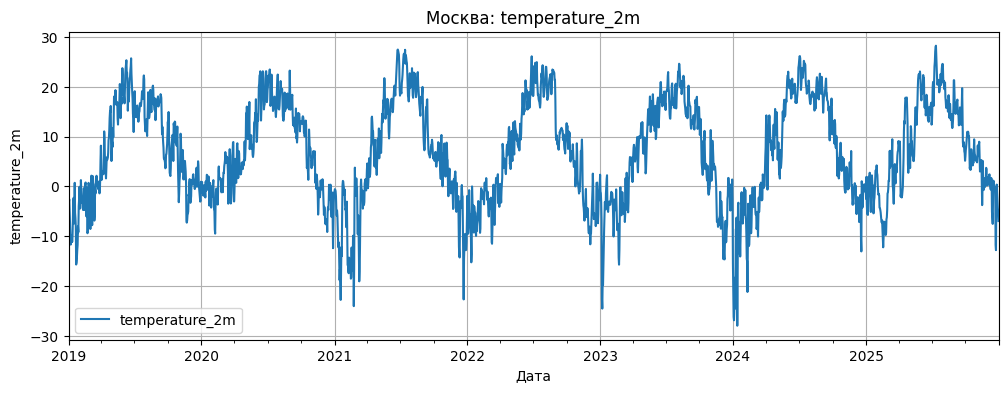

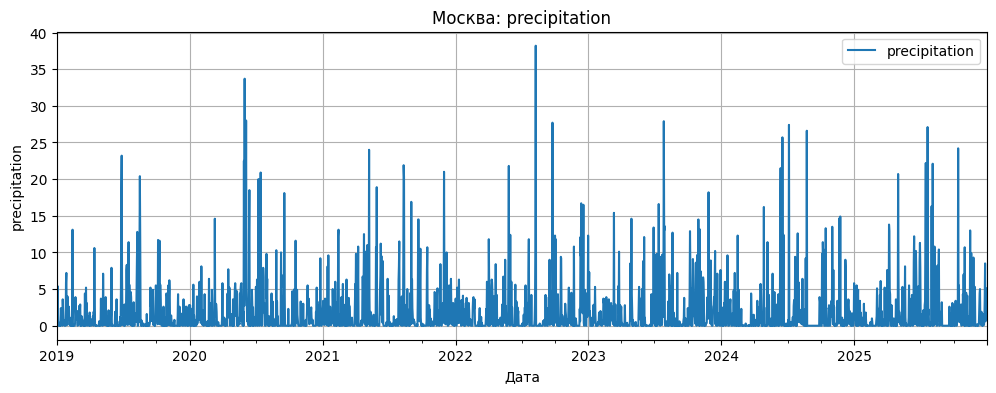

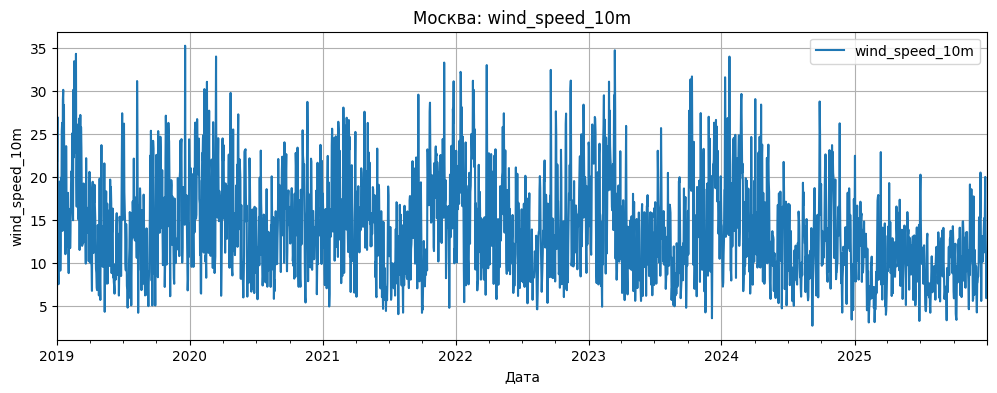

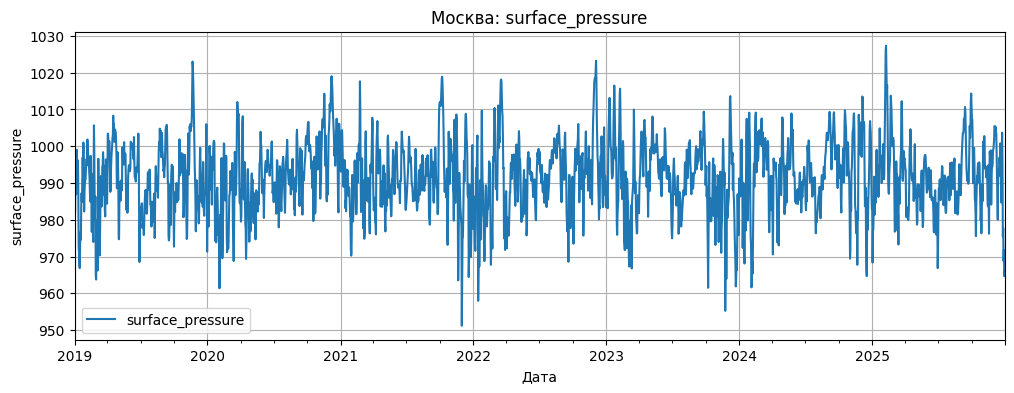

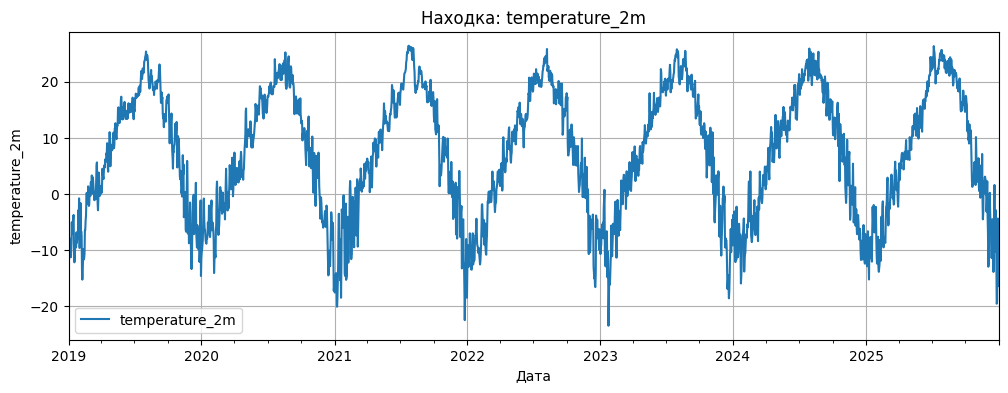

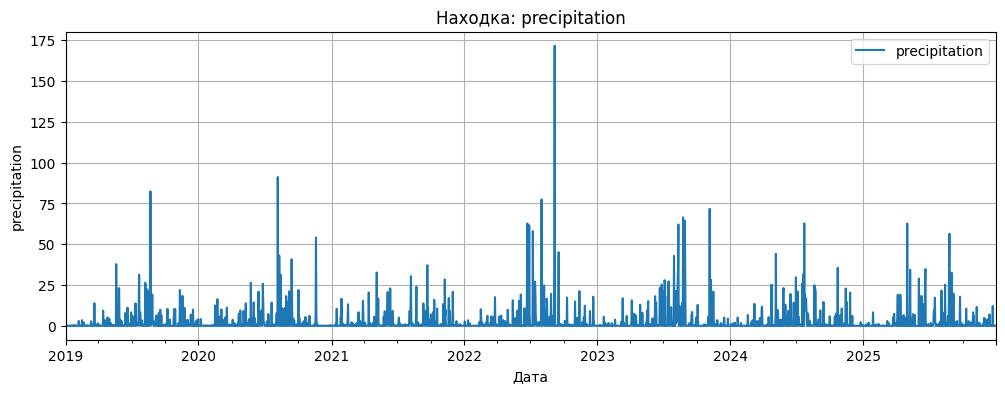

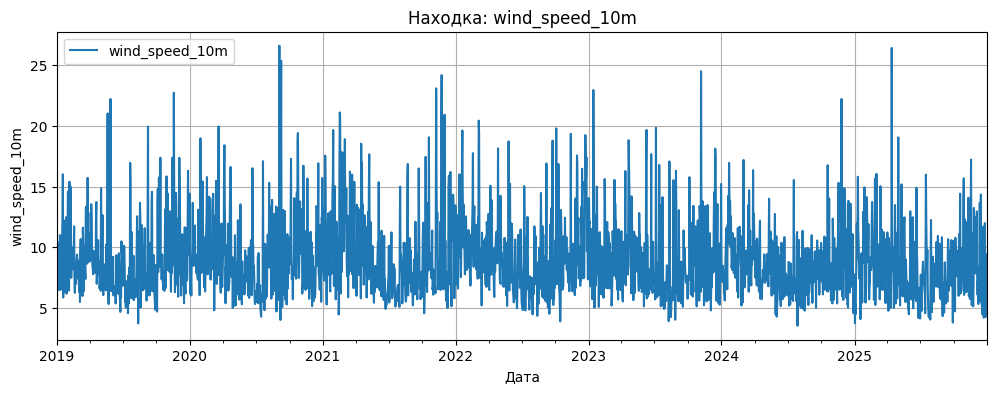

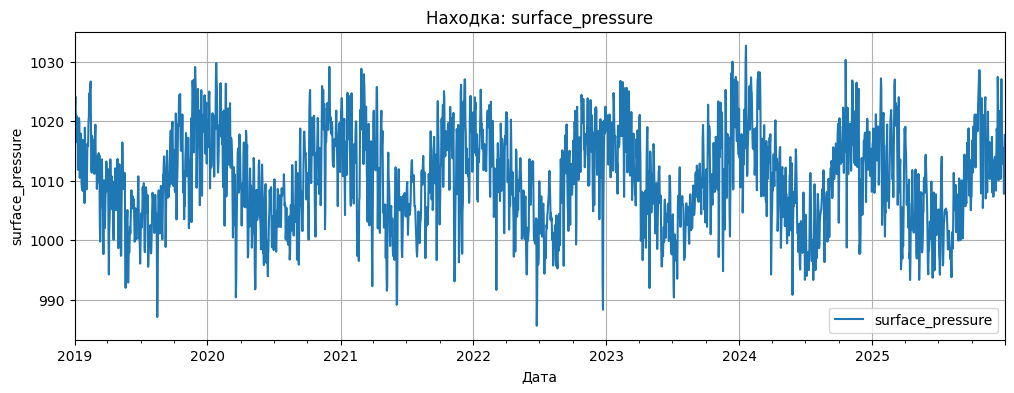

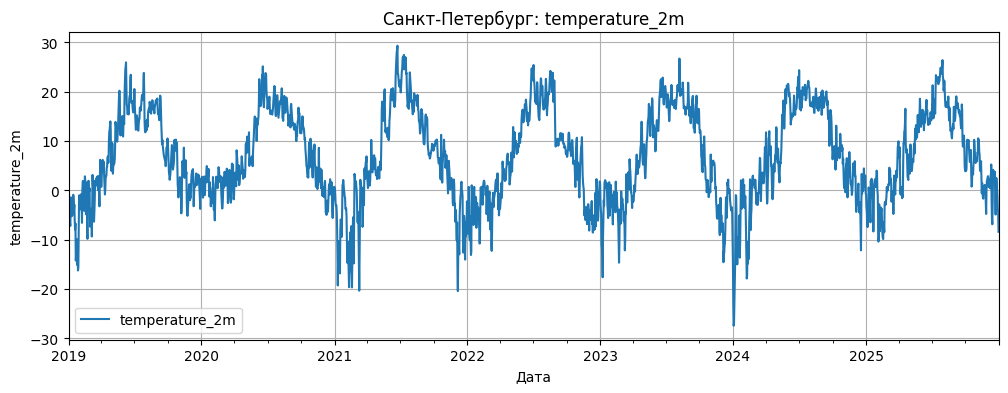

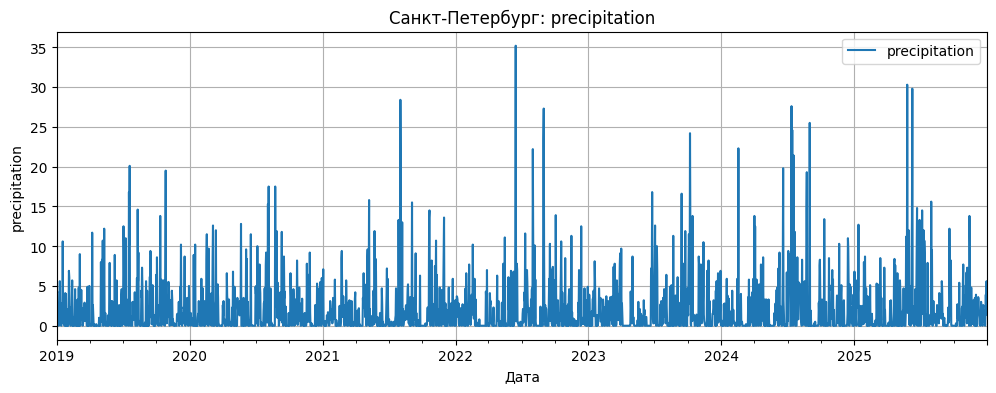

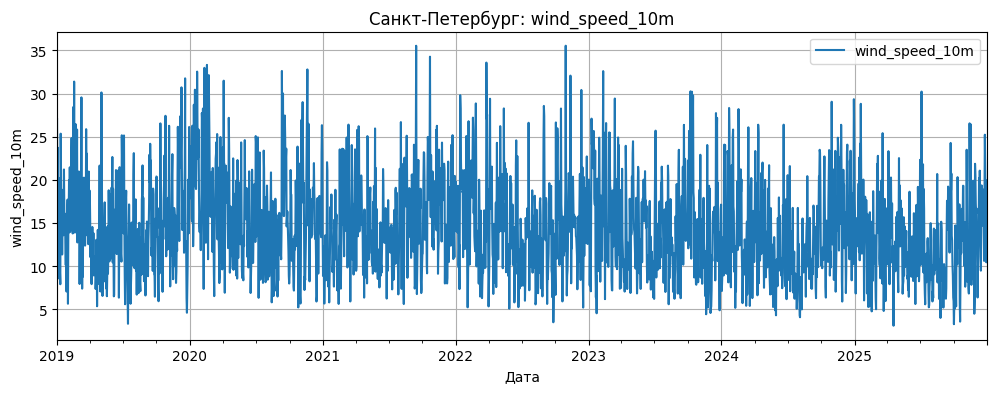

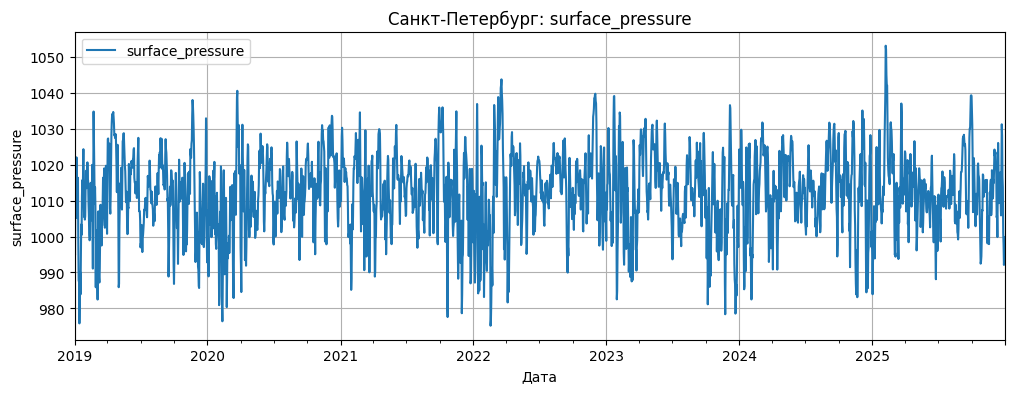

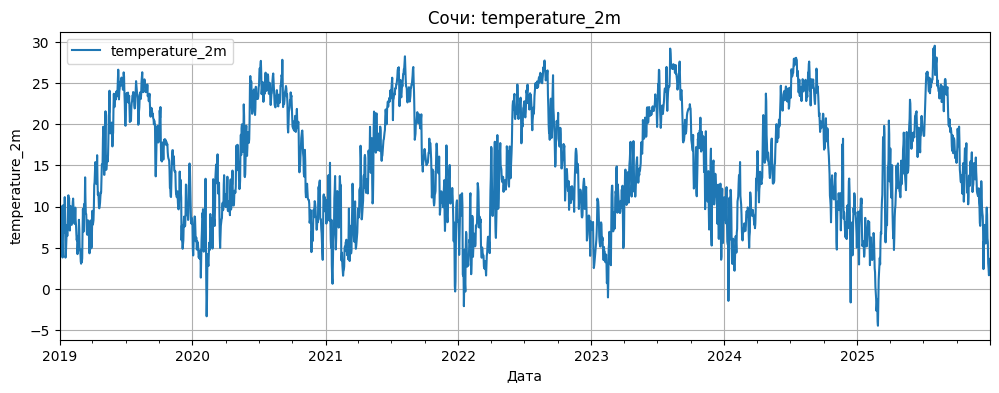

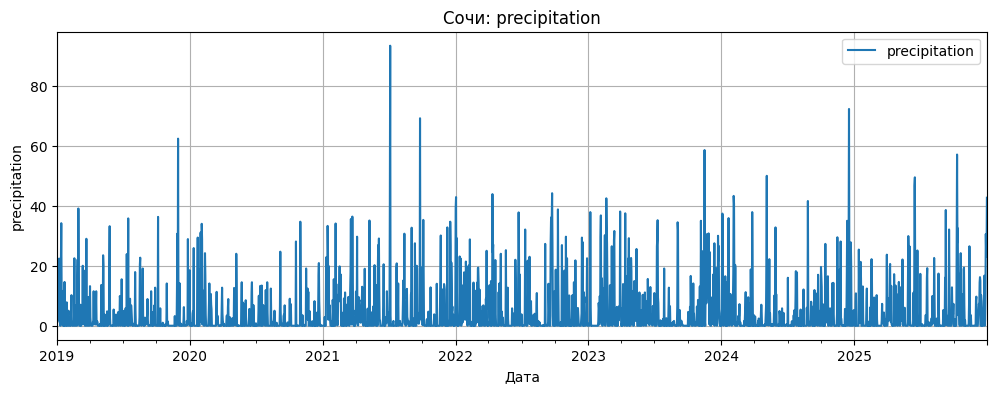

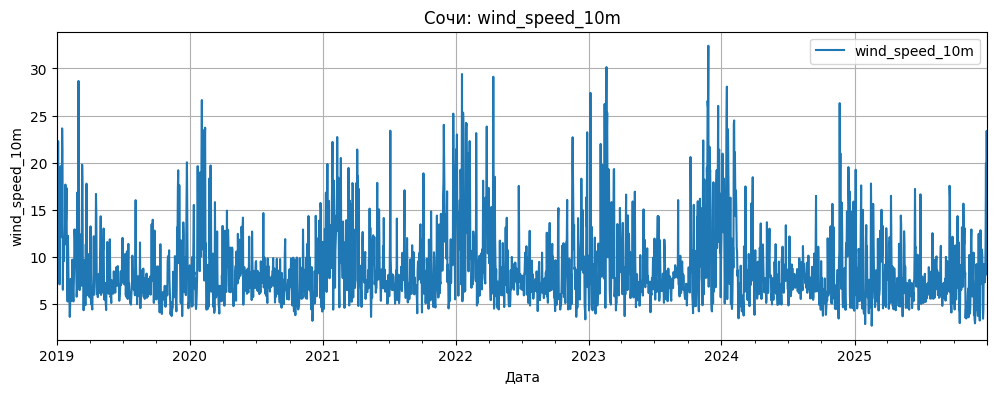

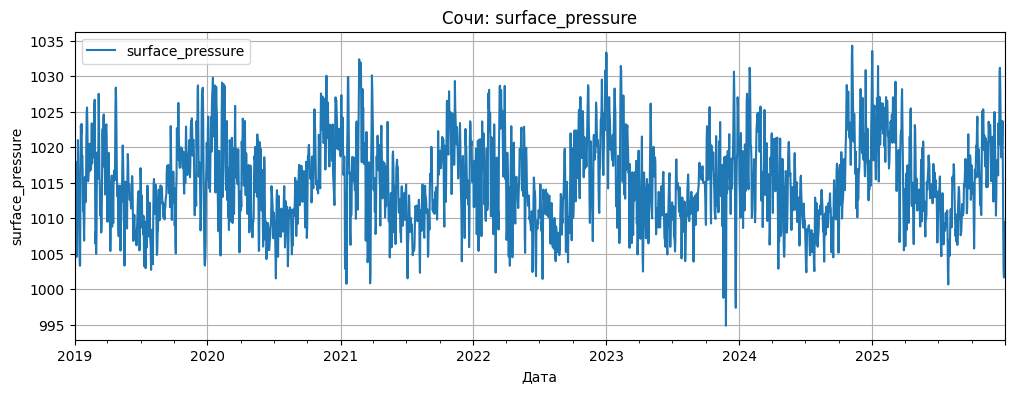

In [ ]:
def plot_city_timeseries(df: pd.DataFrame, city: str, cols: list[str]) -> None:
    city_df = df[df["city"] == city].sort_values("time")
    for col in cols:
        ax = city_df.plot(x="time", y=col, figsize=(12, 4), title=f"{city}: {col}")
        ax.set_xlabel("Дата")
        ax.set_ylabel(col)
        plt.show()


for city in sorted(daily_df["city"].unique()):
    plot_city_timeseries(
        daily_df,
        city,
        ["temperature_2m", "precipitation", "wind_speed_10m", "surface_pressure"],
    )

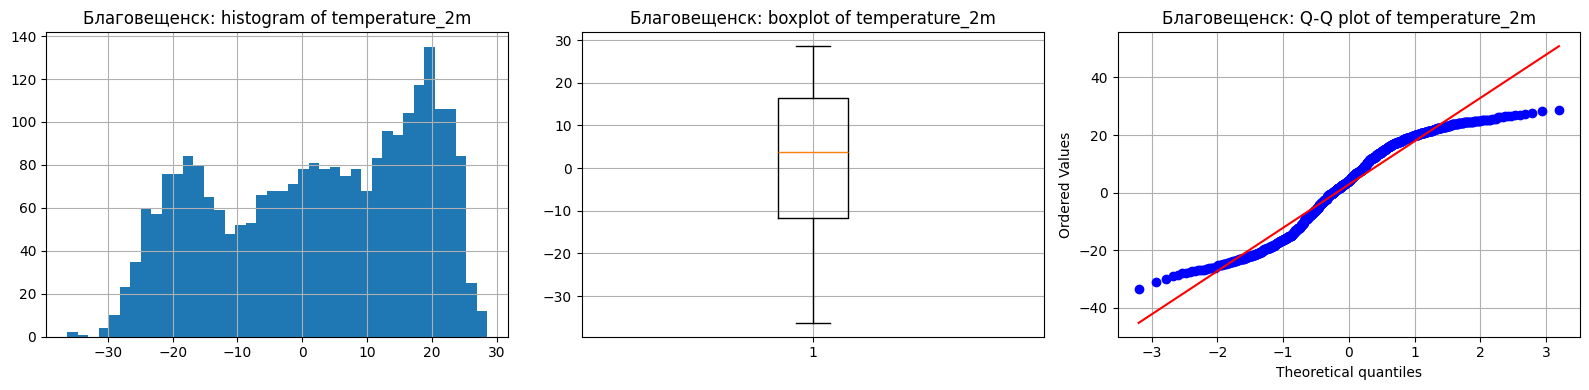

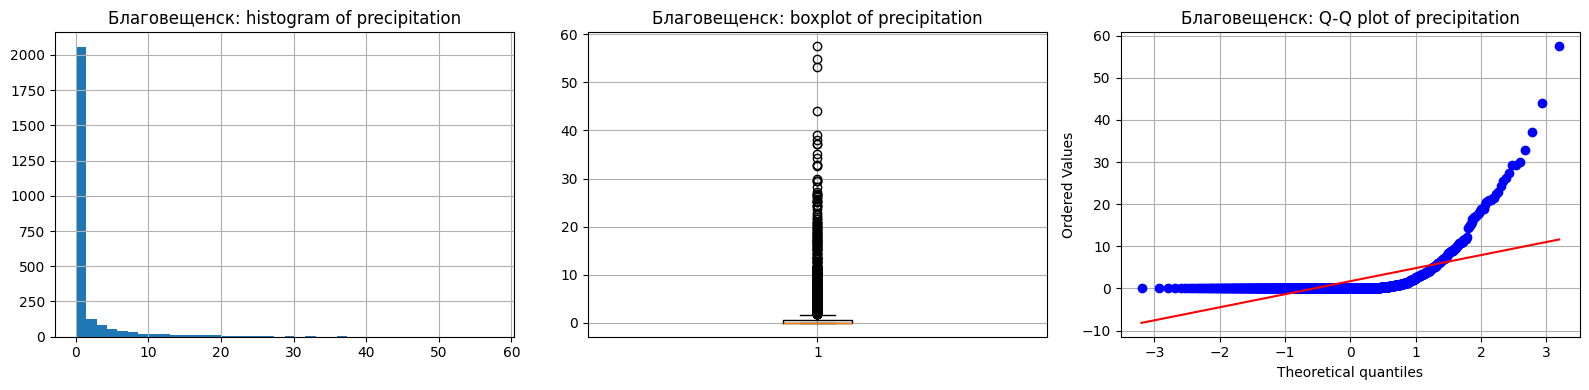

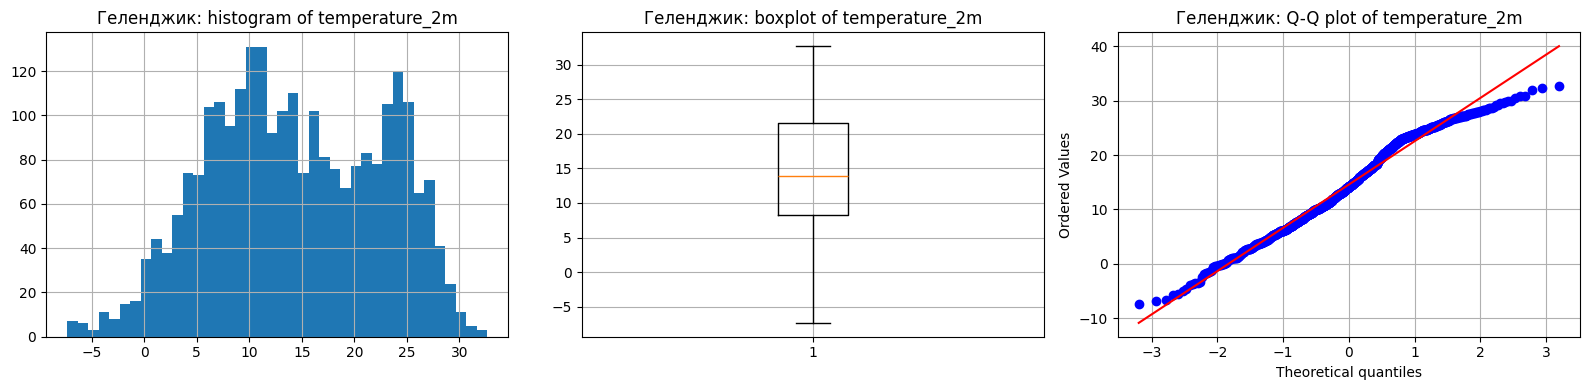

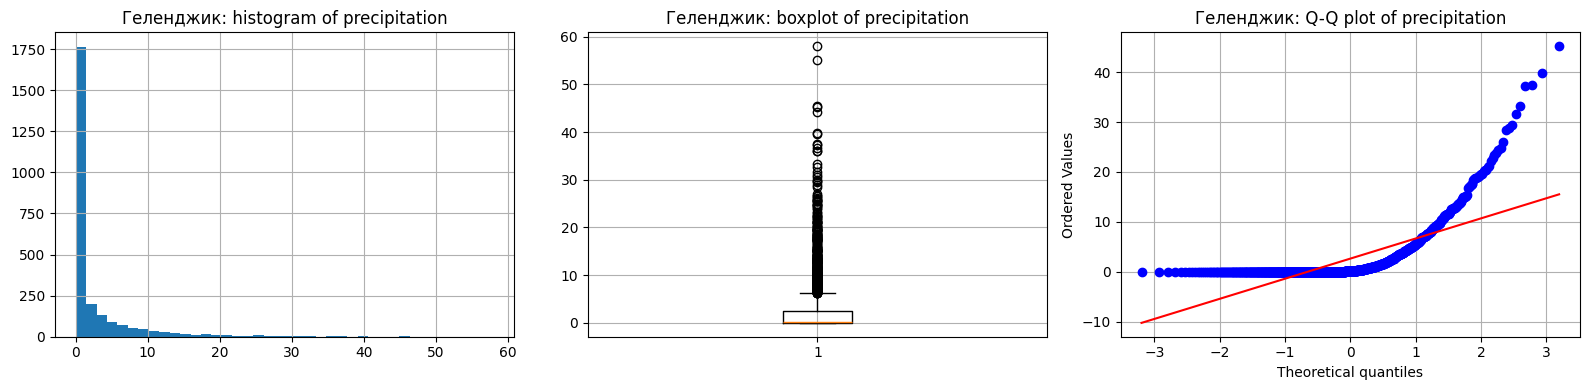

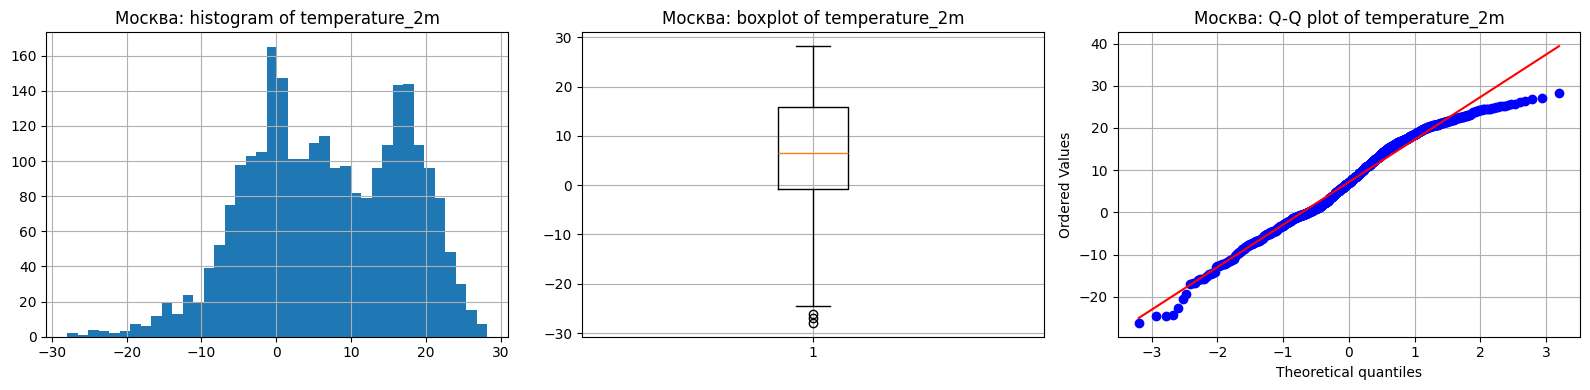

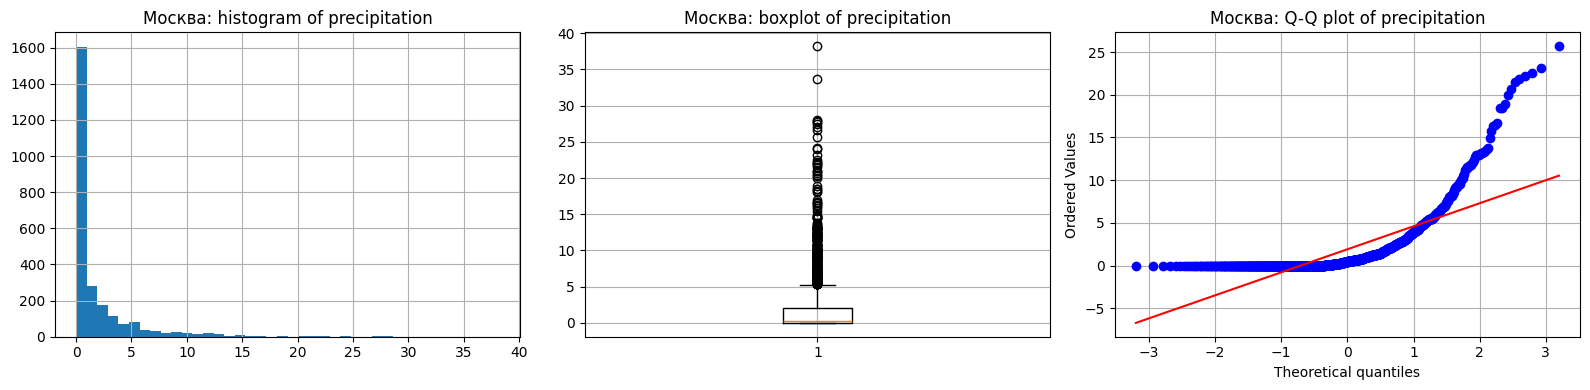

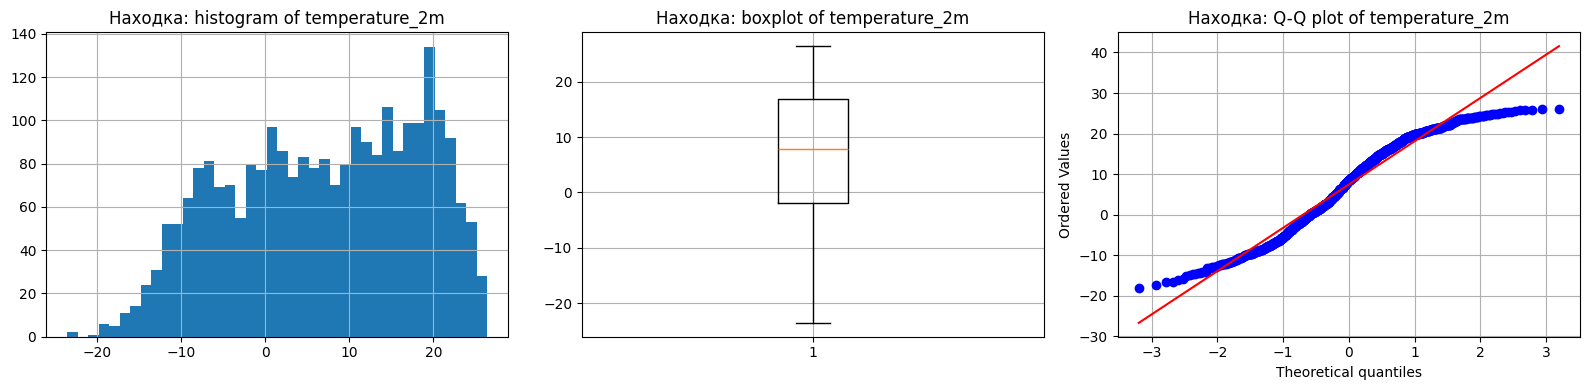

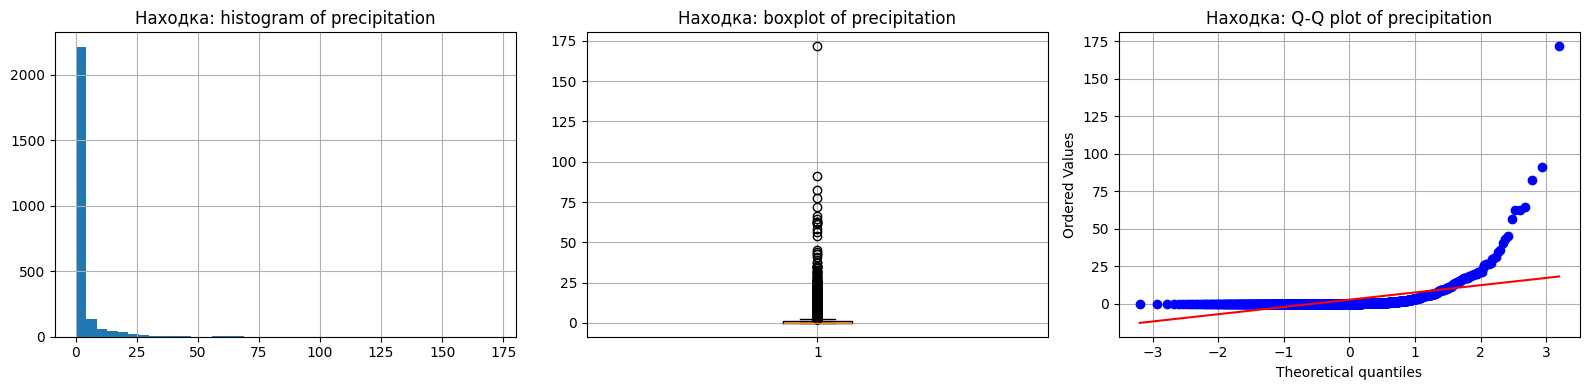

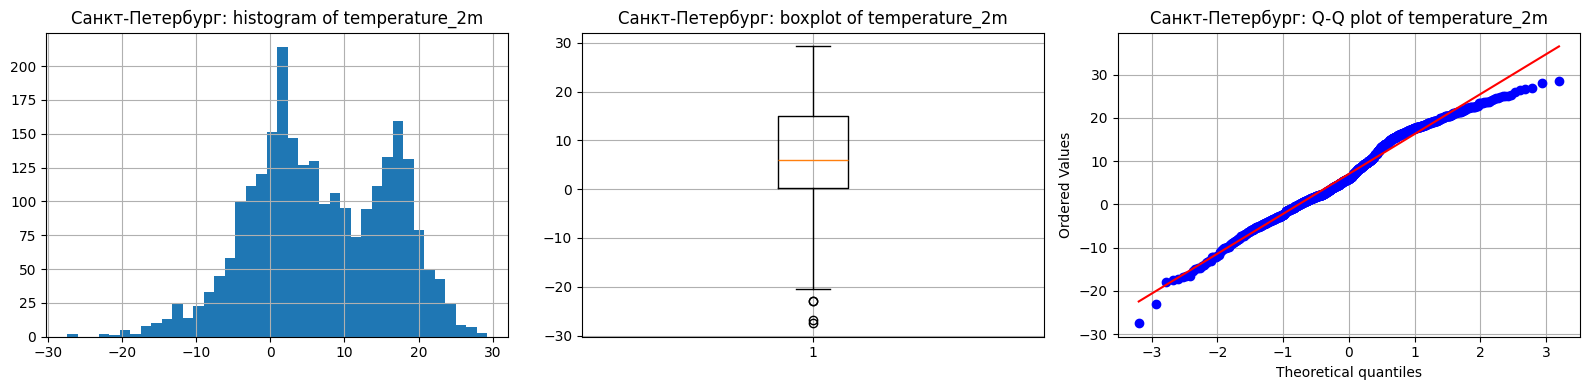

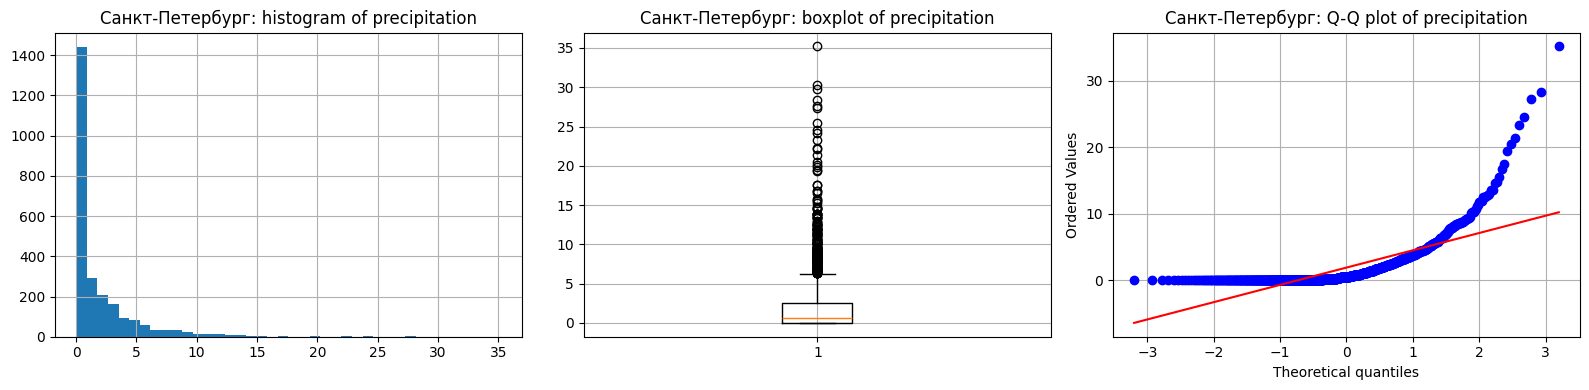

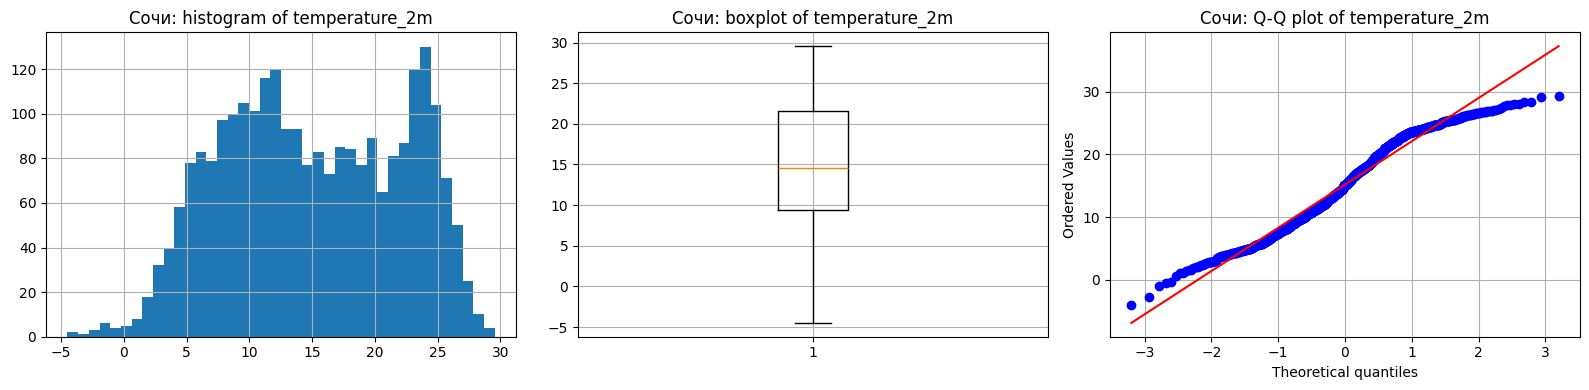

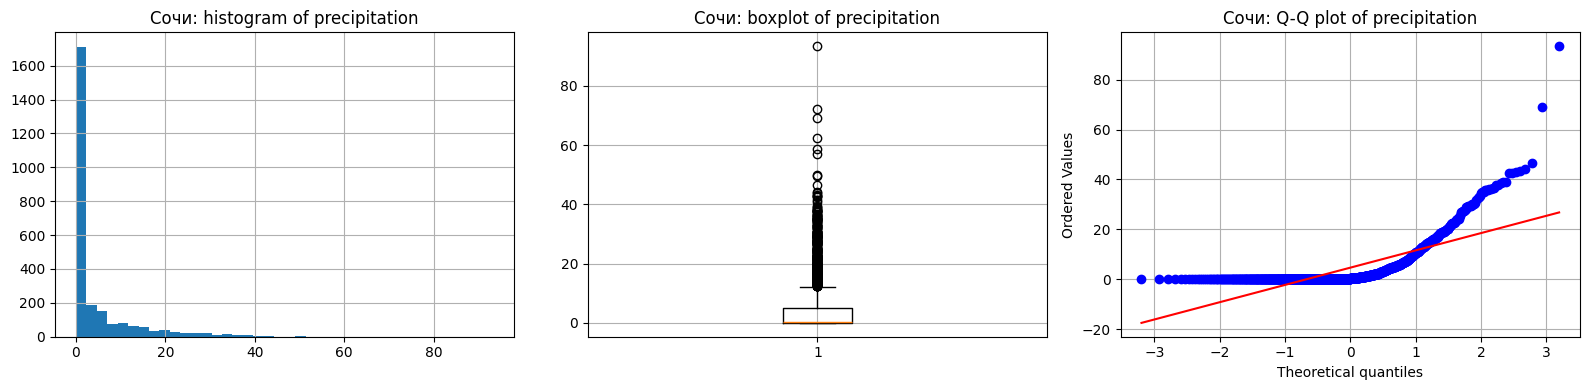

In [ ]:
def distribution_plots(df: pd.DataFrame, city: str, col: str) -> None:
    sub = df[df["city"] == city][col].dropna()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].hist(sub, bins=40)
    axes[0].set_title(f"{city}: histogram of {col}")

    axes[1].boxplot(sub, vert=True)
    axes[1].set_title(f"{city}: boxplot of {col}")

    stats.probplot(sub.sample(min(len(sub), 1000), random_state=RANDOM_STATE), dist="norm", plot=axes[2])
    axes[2].set_title(f"{city}: Q-Q plot of {col}")
    plt.tight_layout()
    plt.show()


for city in sorted(daily_df["city"].unique()):
    distribution_plots(daily_df, city, "temperature_2m")
    distribution_plots(daily_df, city, "precipitation")

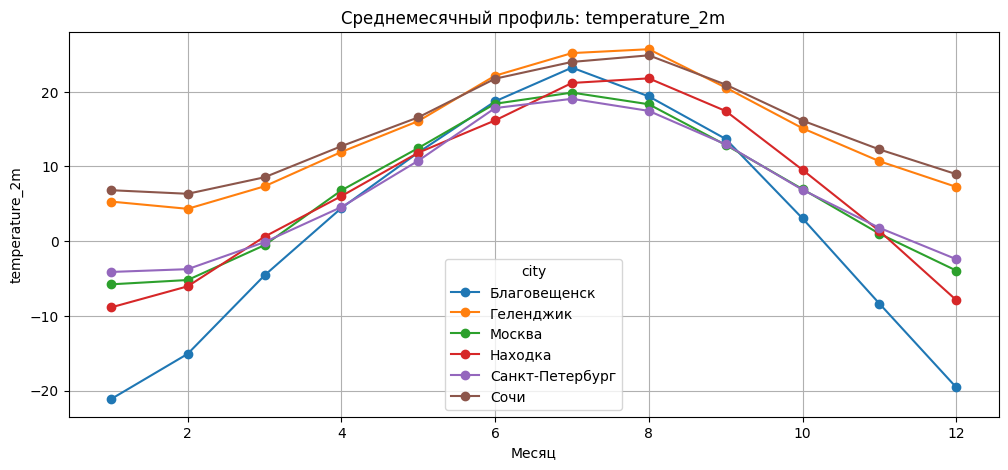

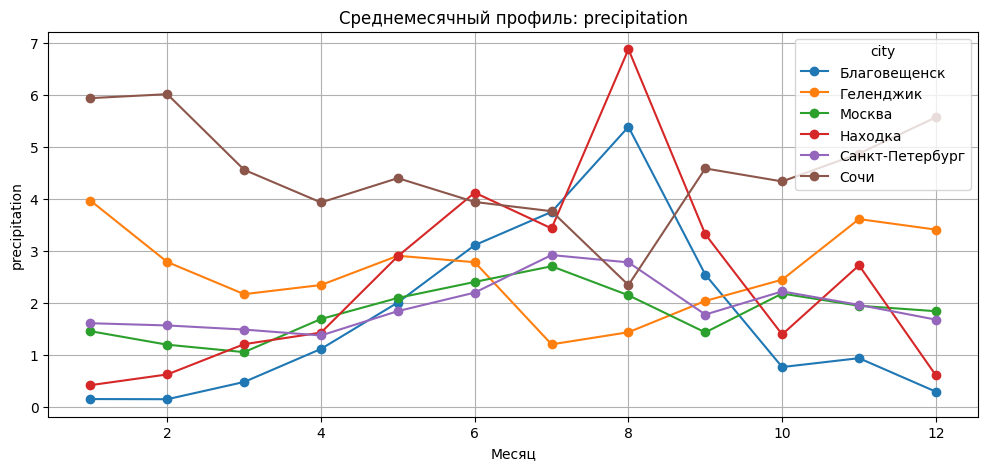

In [ ]:
monthly_profiles = (
    daily_df.groupby(["city", "month"])
    .agg(
        temperature_2m=("temperature_2m", "mean"),
        precipitation=("precipitation", "mean"),
        wind_speed_10m=("wind_speed_10m", "mean"),
        surface_pressure=("surface_pressure", "mean"),
    )
    .reset_index()
)

for feature in ["temperature_2m", "precipitation"]:
    pivot = monthly_profiles.pivot(index="month", columns="city", values=feature)
    pivot.plot(marker="o", title=f"Среднемесячный профиль: {feature}")
    plt.xlabel("Месяц")
    plt.ylabel(feature)
    plt.show()

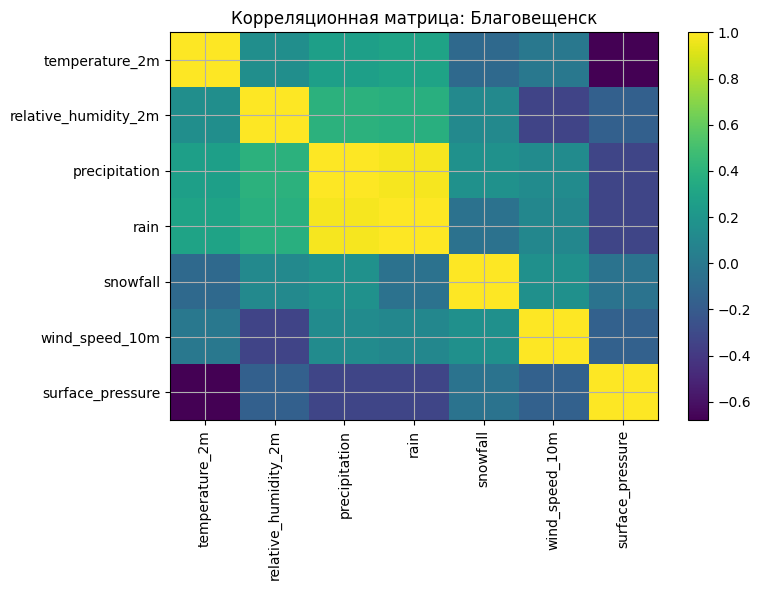

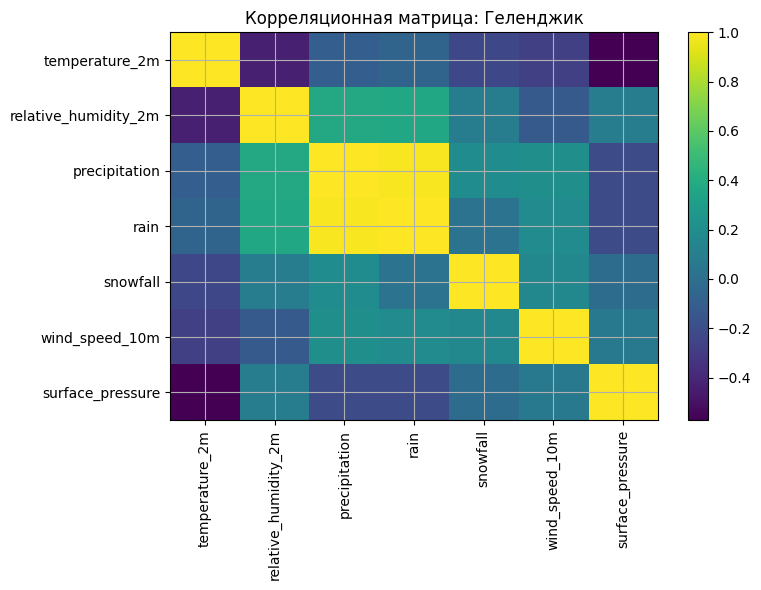

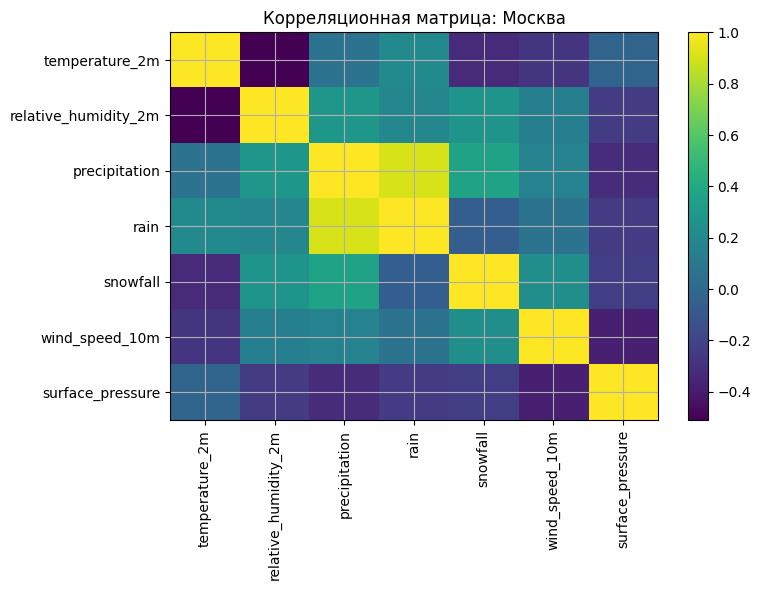

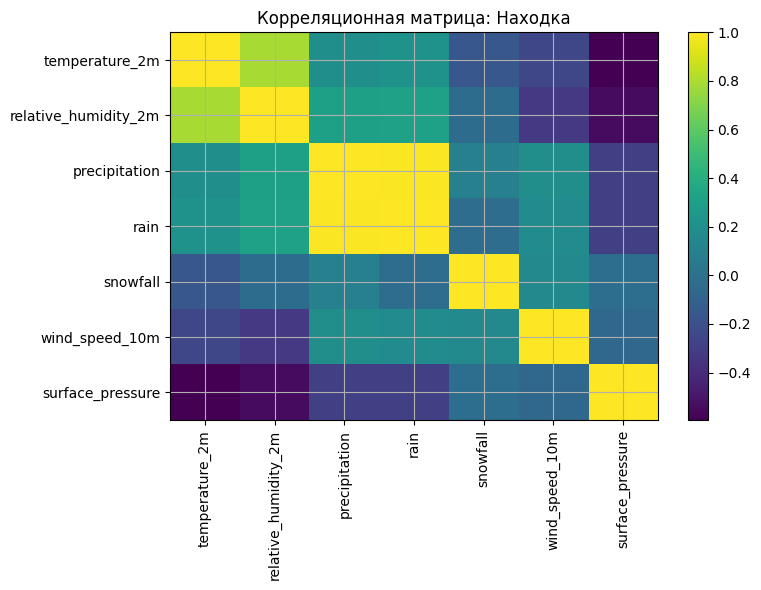

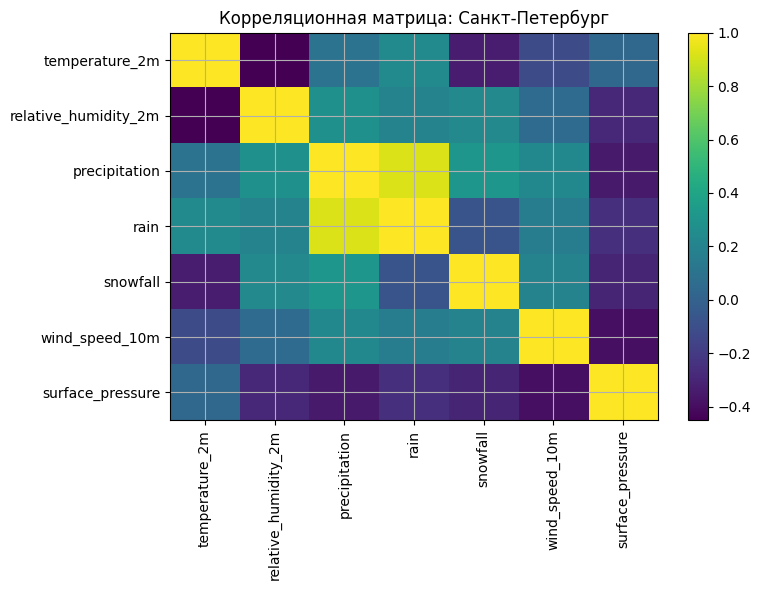

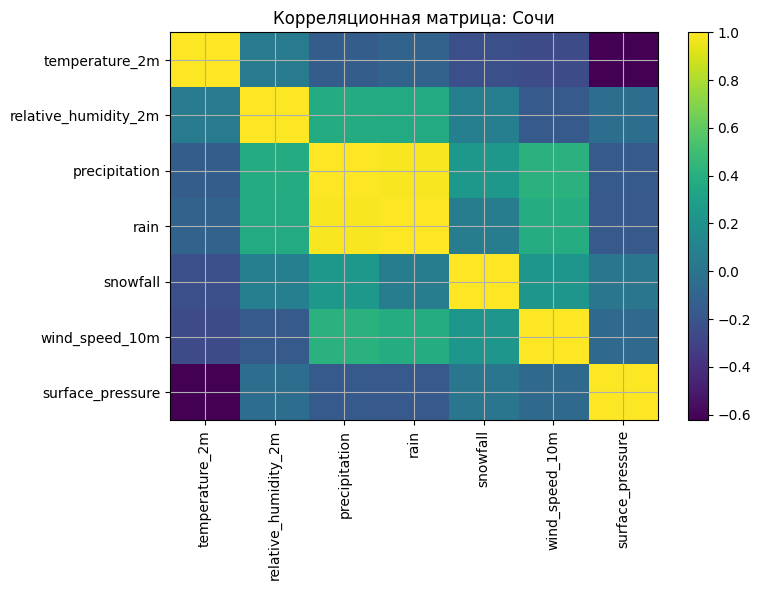

In [ ]:
for city in sorted(daily_df["city"].unique()):
    corr = daily_df[daily_df["city"] == city][[
        "temperature_2m",
        "relative_humidity_2m",
        "precipitation",
        "rain",
        "snowfall",
        "wind_speed_10m",
        "surface_pressure",
    ]].corr()

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr, aspect="auto")
    ax.set_title(f"Корреляционная матрица: {city}")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels(corr.columns)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

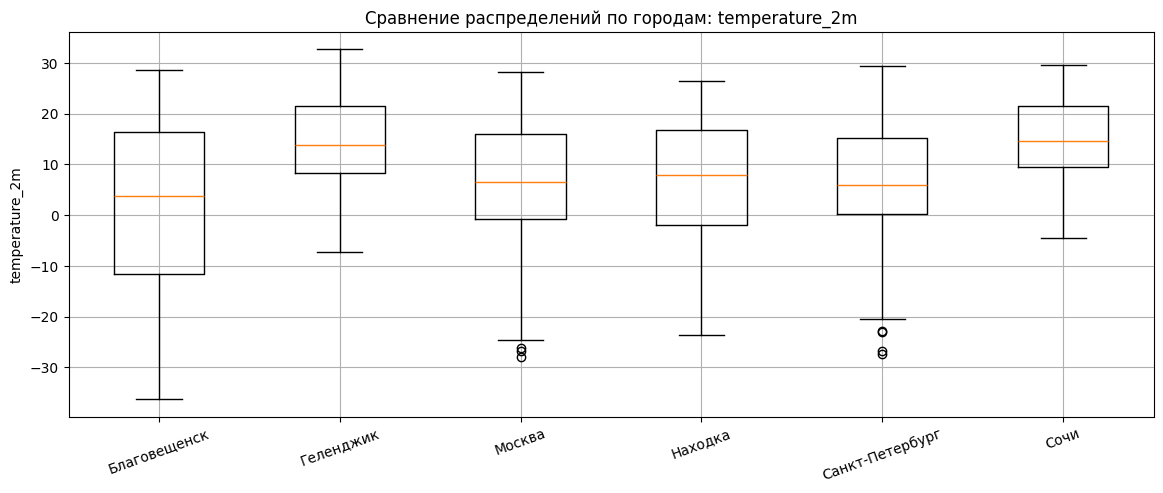

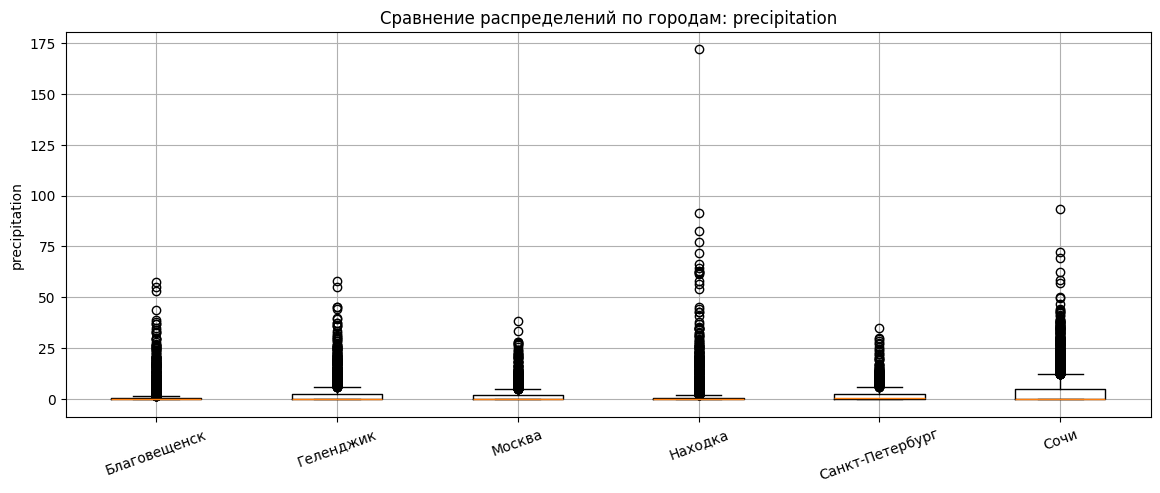

In [ ]:
# Межгородское сравнение распределений температуры и осадков
for feature in ["temperature_2m", "precipitation"]:
    fig, ax = plt.subplots(figsize=(14, 5))
    data = [daily_df.loc[daily_df["city"] == city, feature].dropna().values for city in sorted(daily_df["city"].unique())]
    ax.boxplot(data, tick_labels=sorted(daily_df["city"].unique()))
    ax.set_title(f"Сравнение распределений по городам: {feature}")
    ax.set_ylabel(feature)
    plt.xticks(rotation=20)
    plt.show()

In [ ]:
missing_report = (
    raw_df[BASE_FEATURES + ["city"]]
    .groupby("city")
    .apply(lambda x: x.isna().sum())
)
display(missing_report)

print("Итог по пропускам:")
print(raw_df[BASE_FEATURES].isna().sum().sort_values(ascending=False))

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
city,,,,,,,,
Благовещенск,0,0,0,0,0,0,0,0
Геленджик,0,0,0,0,0,0,0,0
Москва,0,0,0,0,0,0,0,0
Находка,0,0,0,0,0,0,0,0
Санкт-Петербург,0,0,0,0,0,0,0,0
Сочи,0,0,0,0,0,0,0,0


Итог по пропускам:
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
dtype: int64


#### Обоснование обработки пропусков
В большинстве случаев пропуски у метеоданных имеют выраженную временную структуру, так что базовая стратегия:

- короткие разрывы: **time interpolation**;
- более длинные: восстановление по сезонной норме / соседним периодам;
- при полном отсутствии пропусков — интерполяция не применяется.

В этом наборе пропуски минимальны, поэтому исходные сведения можно использовать практически без восстановления.

In [ ]:
def adf_report(df: pd.DataFrame, col: str = "temperature_2m") -> pd.DataFrame:
    rows = []
    for city, g in df.groupby("city"):
        series = g.sort_values("time")[col].dropna()
        stat, pvalue, *_ = adfuller(series)
        rows.append({"city": city, "feature": col, "adf_pvalue": pvalue, "stationary_at_5pct": pvalue < 0.05})
    return pd.DataFrame(rows).sort_values("adf_pvalue")


adf_results = adf_report(daily_df, "temperature_2m")
display(adf_results)

,city,feature,adf_pvalue,stationary_at_5pct
0,Благовещенск,temperature_2m,0.013476,True
4,Санкт-Петербург,temperature_2m,0.020960,True
2,Москва,temperature_2m,0.022534,True
5,Сочи,temperature_2m,0.026736,True
1,Геленджик,temperature_2m,0.033897,True
3,Находка,temperature_2m,0.051902,False


In [ ]:
# Дифференцирование при необходимости
daily_df["temperature_diff_1"] = daily_df.groupby("city")["temperature_2m"].diff()
daily_df["pressure_growth"] = daily_df.groupby("city")["surface_pressure"].pct_change()
daily_df["temp_velocity"] = daily_df.groupby("city")["temperature_2m"].diff()
daily_df["temp_acceleration"] = daily_df.groupby("city")["temp_velocity"].diff()

display(
    daily_df[["city", "time", "temperature_2m", "temperature_diff_1", "temp_velocity", "temp_acceleration", "pressure_growth"]].head(10)
)

,city,time,temperature_2m,temperature_diff_1,temp_velocity,temp_acceleration,pressure_growth
0,Благовещенск,2019-01-01,-14.037499,NaN,NaN,NaN,NaN
1,Благовещенск,2019-01-02,-18.391666,-4.354167,-4.354167,NaN,0.002533
2,Благовещенск,2019-01-03,-18.770834,-0.379168,-0.379168,3.974999,-0.000540
3,Благовещенск,2019-01-04,-20.787500,-2.016666,-2.016666,-1.637499,-0.005724
4,Благовещенск,2019-01-05,-19.866667,0.920834,0.920834,2.937500,0.002961
5,Благовещенск,2019-01-06,-19.300001,0.566666,0.566666,-0.354168,0.003321
6,Благовещенск,2019-01-07,-21.875000,-2.574999,-2.574999,-3.141665,-0.005391
7,Благовещенск,2019-01-08,-18.850000,3.025000,3.025000,5.599998,-0.002304
8,Благовещенск,2019-01-09,-15.887500,2.962501,2.962501,-0.062499,-0.008918
9,Благовещенск,2019-01-10,-16.091667,-0.204167,-0.204167,-3.166668,0.006211


#### Вывод по стационарности
В сырых температурных рядов чаще всего наблюдается сезонная нестационарность, поэтому:
- для исследованиеа динамики полезно использовать **первые разности**;
- для прогноза сохраняются как исходные уровни, так и динамические признаки;
- полный отказ от исходного уровня температуры крайне нежелателен, потому что он несёт физически важную информацию.

## 4. Инжиниринг признаков

In [ ]:
def add_lag_features(df: pd.DataFrame, group_col: str, target_cols: list[str], lags: list[int]) -> pd.DataFrame:
    out = df.copy()
    for col in target_cols:
        for lag in lags:
            out[f"{col}_lag_{lag}"] = out.groupby(group_col)[col].shift(lag)
    return out


def add_rolling_features(df: pd.DataFrame, group_col: str, target_cols: list[str], windows: list[int]) -> pd.DataFrame:
    out = df.copy()
    for col in target_cols:
        for win in windows:
            grouped = out.groupby(group_col)[col]
            out[f"{col}_roll_mean_{win}"] = grouped.transform(lambda s: s.rolling(win).mean())
            out[f"{col}_roll_std_{win}"] = grouped.transform(lambda s: s.rolling(win).std())
            out[f"{col}_roll_min_{win}"] = grouped.transform(lambda s: s.rolling(win).min())
            out[f"{col}_roll_max_{win}"] = grouped.transform(lambda s: s.rolling(win).max())
    return out


daily_features_df = add_lag_features(
    daily_df,
    group_col="city",
    target_cols=["temperature_2m", "precipitation", "surface_pressure", "wind_speed_10m"],
    lags=[1, 3, 7, 14, 30],
)

daily_features_df = add_rolling_features(
    daily_features_df,
    group_col="city",
    target_cols=["temperature_2m", "precipitation", "surface_pressure"],
    windows=[3, 7, 14, 30],
)

# Климатическая норма по дню года
clim_norm = (
    daily_features_df.groupby(["city", "dayofyear"])["temperature_2m"]
    .mean()
    .rename("temperature_clim_norm")
    .reset_index()
)

daily_features_df = daily_features_df.merge(clim_norm, on=["city", "dayofyear"], how="left")
daily_features_df["temperature_anomaly"] = daily_features_df["temperature_2m"] - daily_features_df["temperature_clim_norm"]

display(daily_features_df.head())

,city,time,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,...,surface_pressure_roll_mean_14,surface_pressure_roll_std_14,surface_pressure_roll_min_14,surface_pressure_roll_max_14,surface_pressure_roll_mean_30,surface_pressure_roll_std_30,surface_pressure_roll_min_30,surface_pressure_roll_max_30,temperature_clim_norm,temperature_anomaly
0,Благовещенск,2019-01-01,-14.037499,63.083333,0.0,0.0,0.0,0.0,13.400001,1008.362488,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21.332142,7.294642
1,Благовещенск,2019-01-02,-18.391666,72.875000,0.0,0.0,0.0,0.0,10.904167,1010.916687,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21.717260,3.325594
2,Благовещенск,2019-01-03,-18.770834,70.041667,0.0,0.0,0.0,0.0,8.770833,1010.370850,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-20.859524,2.088690
3,Благовещенск,2019-01-04,-20.787500,75.166667,0.0,0.0,0.0,3.0,8.083333,1004.587463,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-22.103573,1.316072
4,Благовещенск,2019-01-05,-19.866667,72.333333,0.0,0.0,0.0,0.0,10.708333,1007.562500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21.524405,1.657738


#### Обоснование лагов и окон
Используются лаги `1, 3, 7, 14, 30` дней:
- 1–3 дня — краткосрочная инерция процесса;
- 7 дней — недельный квазицикл;
- 14 дней — переходные синоптические режимы;
- 30 дней — фон месяца и сезонный контекст.

Скользящие окна `3, 7, 14, 30` дней показывают:
- локальную изменчивость,
- недельную сглаженную динамику,
- двухнедельные перестройки,
- месячную климатическую компоненту.

## 5. Признаки для классификации климатического типа

In [ ]:
def safe_trend(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    if len(values) < 2 or np.all(np.isnan(values)):
        return 0.0
    x = np.arange(len(values))
    try:
        return float(np.polyfit(x, values, 1)[0])
    except Exception:
        return 0.0


def build_classification_windows(df: pd.DataFrame, window: int = 30, step: int = 15) -> pd.DataFrame:
    rows = []
    for city, g in df.groupby("city"):
        g = g.sort_values("time").reset_index(drop=True)
        for start in range(0, len(g) - window + 1, step):
            w = g.iloc[start:start + window]
            row = {
                "city": city,
                "climate_type": w["climate_type"].iloc[0],
                "start_time": w["time"].iloc[0],
                "end_time": w["time"].iloc[-1],
                "month": int(w["time"].dt.month.mode().iloc[0]),
                "season": w["season"].mode().iloc[0],
            }
            for col in [
                "temperature_2m",
                "relative_humidity_2m",
                "precipitation",
                "rain",
                "snowfall",
                "wind_speed_10m",
                "surface_pressure",
            ]:
                values = w[col].values
                row[f"{col}_mean"] = np.mean(values)
                row[f"{col}_std"] = np.std(values)
                row[f"{col}_min"] = np.min(values)
                row[f"{col}_max"] = np.max(values)
                row[f"{col}_trend"] = safe_trend(values)

            row["temp_amplitude"] = w["temperature_2m"].max() - w["temperature_2m"].min()
            row["wet_days_share"] = float((w["precipitation"] > 0).mean())
            row["max_wind_gust_proxy"] = float(w["wind_speed_10m"].max())
            row["mean_temp"] = float(w["temperature_2m"].mean())
            row["std_temp"] = float(w["temperature_2m"].std())
            rows.append(row)

    return pd.DataFrame(rows)


clf_df = build_classification_windows(daily_features_df, window=30, step=15)
display(clf_df.head())
print(clf_df.shape)

,city,climate_type,start_time,end_time,month,season,temperature_2m_mean,temperature_2m_std,temperature_2m_min,temperature_2m_max,...,surface_pressure_mean,surface_pressure_std,surface_pressure_min,surface_pressure_max,surface_pressure_trend,temp_amplitude,wet_days_share,max_wind_gust_proxy,mean_temp,std_temp
0,Благовещенск,дальневосточный,2019-01-01,2019-01-30,1,winter,-17.980278,2.909392,-24.312500,-12.991666,...,1003.387390,5.309099,993.004150,1011.049988,-0.313396,11.320834,0.200000,16.949999,-17.980278,2.959129
1,Благовещенск,дальневосточный,2019-01-16,2019-02-14,1,winter,-19.831245,4.640686,-28.766668,-12.991666,...,1003.061523,5.186585,993.004150,1011.262512,0.293117,15.775002,0.200000,16.949999,-19.831245,4.720019
2,Благовещенск,дальневосточный,2019-01-31,2019-03-01,2,winter,-14.799166,8.301040,-28.766668,-3.229167,...,1002.171875,4.975811,993.075012,1011.262512,-0.185692,25.537502,0.133333,18.824999,-14.799166,8.442949
3,Благовещенск,дальневосточный,2019-02-15,2019-03-16,3,spring,-5.257638,3.093508,-15.545834,-0.616667,...,998.043030,4.543303,986.033386,1005.112488,-0.175696,14.929167,0.233333,19.200001,-5.257638,3.146392
4,Благовещенск,дальневосточный,2019-03-02,2019-03-31,3,spring,-3.744444,2.382531,-8.970834,1.587500,...,996.120483,5.350253,985.104187,1005.112488,-0.054034,10.558334,0.266667,19.200001,-3.744444,2.423261


(1014, 46)


In [ ]:
# one-hot для сезонности
clf_df = pd.get_dummies(clf_df, columns=["season"], drop_first=False)

train_clf = clf_df[clf_df["start_time"].dt.year <= 2023].copy()
val_clf = clf_df[clf_df["start_time"].dt.year == 2024].copy()
test_clf = clf_df[clf_df["start_time"].dt.year == 2025].copy()

drop_cols = ["city", "climate_type", "start_time", "end_time"]
feature_cols_clf = [c for c in clf_df.columns if c not in drop_cols]

X_train_clf = train_clf[feature_cols_clf]
y_train_clf = train_clf["climate_type"]

X_val_clf = val_clf[feature_cols_clf]
y_val_clf = val_clf["climate_type"]

X_test_clf = test_clf[feature_cols_clf]
y_test_clf = test_clf["climate_type"]

print(X_train_clf.shape, X_val_clf.shape, X_test_clf.shape)

(732, 45) (150, 45) (132, 45)


#### Обоснование выбора модели классификации

Выбрана **ансамблевая алгоритм на табличных статистических признаках** (`RandomForestClassifier`), потому что:
- объём задачи не слишком большой;
- в признаках присутствуют нелинейные зависимости и разные масштабы;
- важна интерпретируемость и устойчивость;
- в данном случае не требуется дорогое обучение sequence-моделей.

##### Заведомо не подходящие модели
- **Обычная линейная классификация на сырых рядах** — теряется нелинейность и сезонные паттерны.
- **k-NN на длинных сырых окнах** — плохо масштабируется и имеется чувствительность к шуму.
- **Слишком глубокие нейросети** (LSTM/Transformer) — избыточны для относительно малого числа объектов и повышают риск переобучения.

##### Причины почему задача является сложной
- сезонность частично общая для разных городов;
- внутри одного климата возможны сильные межгодовые различия;
- погода шумная и нестационарная;
- классы различаются не одной переменной, а сочетанием температуры, осадков, давления и ветра.

In [ ]:
clf_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]
)

clf_pipe.fit(X_train_clf, y_train_clf)

val_pred = clf_pipe.predict(X_val_clf)
test_pred = clf_pipe.predict(X_test_clf)
test_proba = clf_pipe.predict_proba(X_test_clf)

print("VAL accuracy:", round(accuracy_score(y_val_clf, val_pred), 4))
print("TEST accuracy:", round(accuracy_score(y_test_clf, test_pred), 4))

VAL accuracy: 0.94
TEST accuracy: 0.7576


## 6. Оценка качества классификации

In [ ]:
metrics_summary = pd.DataFrame(
    {
        "metric": ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted"],
        "value": [
            accuracy_score(y_test_clf, test_pred),
            precision_score(y_test_clf, test_pred, average="macro"),
            recall_score(y_test_clf, test_pred, average="macro"),
            f1_score(y_test_clf, test_pred, average="macro"),
            f1_score(y_test_clf, test_pred, average="weighted"),
        ],
    }
)
display(metrics_summary)

print(classification_report(y_test_clf, test_pred))

,metric,value
0,accuracy,0.757576
1,precision_macro,0.810337
2,recall_macro,0.757576
3,f1_macro,0.738549
4,f1_weighted,0.738549


                          precision    recall  f1-score   support

         дальневосточный       0.60      0.93      0.73        44
  морской субтропический       0.93      0.95      0.94        44
умеренно-континентальный       0.89      0.39      0.54        44

                accuracy                           0.76       132
               macro avg       0.81      0.76      0.74       132
            weighted avg       0.81      0.76      0.74       132



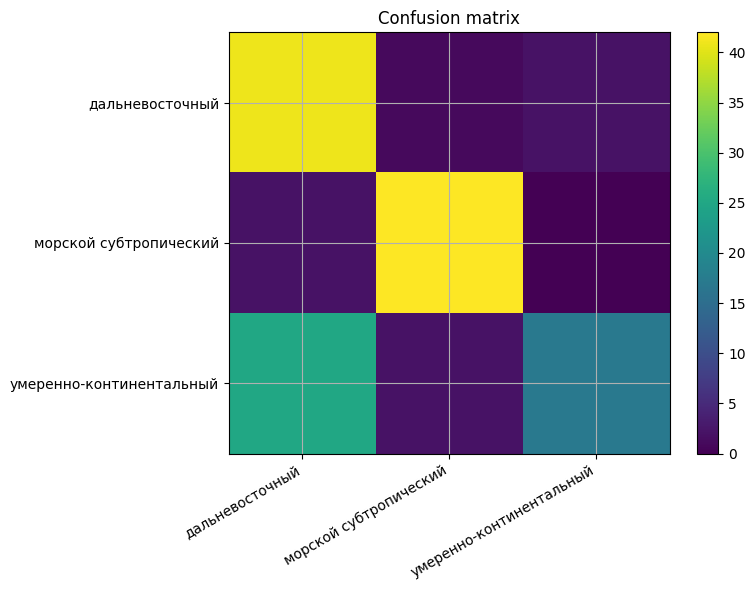

In [ ]:
labels = sorted(y_test_clf.unique())
cm = confusion_matrix(y_test_clf, test_pred, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, aspect="auto")
ax.set_title("Confusion matrix")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [ ]:
y_test_bin = label_binarize(y_test_clf, classes=labels)
roc_auc_ovr = roc_auc_score(y_test_bin, test_proba, multi_class="ovr", average="macro")
print("ROC-AUC OVR (macro):", round(roc_auc_ovr, 4))

ROC-AUC OVR (macro): 0.9406


,month,error_rate
0,1,0.166667
1,2,0.333333
2,3,0.333333
3,4,0.166667
4,5,0.250000
5,6,0.166667
6,7,0.250000
7,8,0.333333
8,9,0.250000
9,10,0.250000


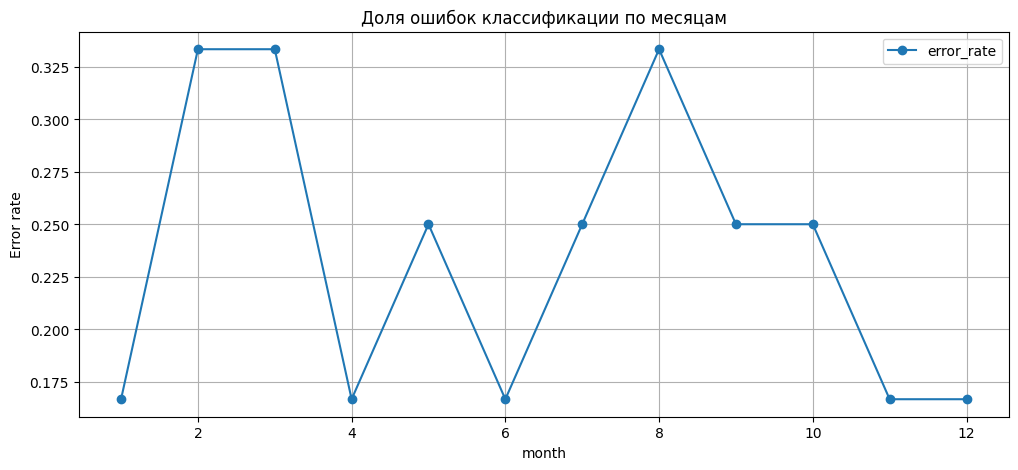

In [ ]:
# Анализ ошибок по месяцам и сезонам
test_eval = test_clf[["city", "climate_type", "month"]].copy()
test_eval["pred"] = test_pred
test_eval["is_error"] = (test_eval["climate_type"] != test_eval["pred"]).astype(int)

monthly_error = test_eval.groupby("month")["is_error"].mean().reset_index(name="error_rate")
display(monthly_error)

monthly_error.plot(x="month", y="error_rate", marker="o", title="Доля ошибок классификации по месяцам")
plt.ylabel("Error rate")
plt.show()

,feature,importance_mean,importance_std
33,surface_pressure_min,0.146212,0.028356
26,wind_speed_10m_mean,0.021970,0.014553
32,surface_pressure_std,0.018182,0.009702
31,surface_pressure_mean,0.013636,0.008159
34,surface_pressure_max,0.008333,0.004080
19,rain_max,0.005303,0.004851
14,precipitation_max,0.005303,0.004851
9,relative_humidity_2m_max,0.005303,0.003472
1,temperature_2m_mean,0.003788,0.008470
15,precipitation_trend,0.003788,0.003788


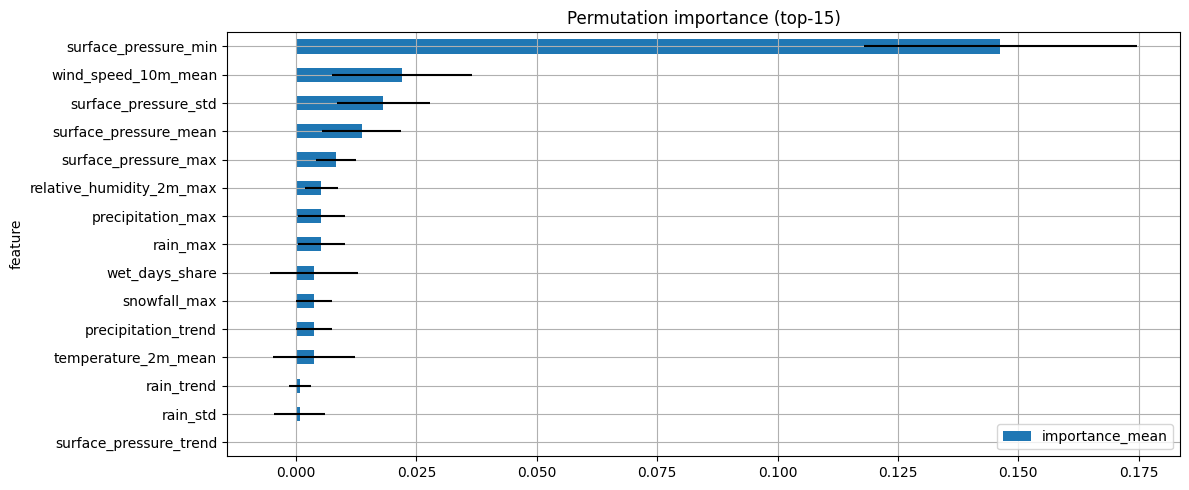

In [ ]:
perm = permutation_importance(
    clf_pipe,
    X_test_clf,
    y_test_clf,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = pd.DataFrame(
    {
        "feature": feature_cols_clf,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)

display(perm_df.head(20))

perm_df.head(15).sort_values("importance_mean").plot.barh(
    x="feature",
    y="importance_mean",
    xerr="importance_std",
    title="Permutation importance (top-15)"
)
plt.tight_layout()
plt.show()

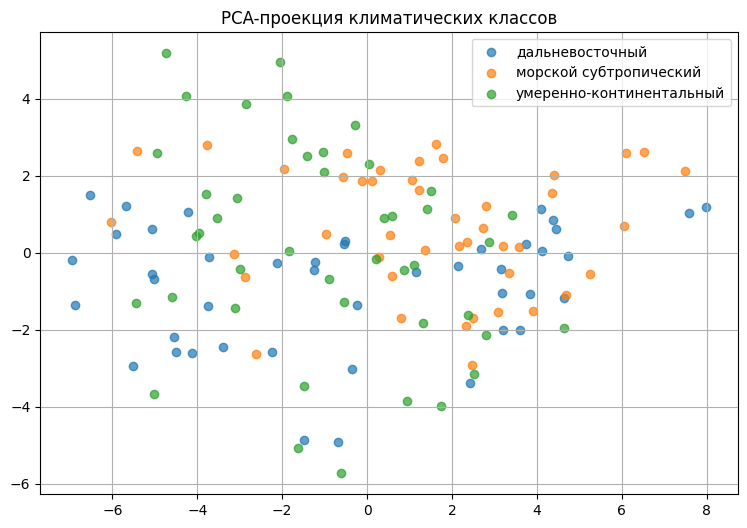

In [ ]:
# PCA-визуализация разделимости
pca_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=RANDOM_STATE)),
])

X_test_pca = pca_pipe.fit_transform(X_test_clf)
pca_vis = pd.DataFrame(X_test_pca, columns=["PC1", "PC2"])
pca_vis["target"] = y_test_clf.values

fig, ax = plt.subplots(figsize=(9, 6))
for target, sub in pca_vis.groupby("target"):
    ax.scatter(sub["PC1"], sub["PC2"], label=target, alpha=0.7)
ax.set_title("PCA-проекция климатических классов")
ax.legend()
plt.show()

#### Вывод по классификации
Лучше и естественнее интерпретируются ошибки между климатами, имеющими частично схожие сезонные профили.  
Permutation importance в большинстве своём показывает высокую значимость:
- температурной амплитуды,
- средней температуры,
- доли влажных дней,
- признаков давления и ветра.

## 7. Подготовка датасета для прогнозирования

In [ ]:
FORECAST_BASE_COLS = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "wind_speed_10m",
    "surface_pressure",
]


def build_forecast_dataset(
    city_df: pd.DataFrame,
    target: str = "temperature_2m",
    history: int = 30,
    horizon: int = 30,
) -> tuple[pd.DataFrame, np.ndarray, pd.Series]:
    city_df = city_df.sort_values("time").reset_index(drop=True).copy()

    rows = []
    targets = []
    meta = []

    for i in range(history, len(city_df) - horizon + 1):
        hist = city_df.iloc[i - history:i]
        current = city_df.iloc[i]

        feat = {}
        for col in FORECAST_BASE_COLS:
            values = hist[col].values
            feat[f"{col}_last"] = values[-1]
            feat[f"{col}_mean_7"] = values[-7:].mean()
            feat[f"{col}_mean_14"] = values[-14:].mean()
            feat[f"{col}_mean_30"] = values.mean()
            feat[f"{col}_std_7"] = values[-7:].std()
            feat[f"{col}_std_30"] = values.std()
            feat[f"{col}_min_30"] = values.min()
            feat[f"{col}_max_30"] = values.max()
            feat[f"{col}_trend_7"] = safe_trend(values[-7:])
            feat[f"{col}_trend_30"] = safe_trend(values)

        feat["dayofweek"] = current["dayofweek"]
        feat["month"] = current["month"]
        feat["dayofyear"] = current["dayofyear"]
        feat["month_sin"] = current["month_sin"]
        feat["month_cos"] = current["month_cos"]
        feat["doy_sin"] = current["doy_sin"]
        feat["doy_cos"] = current["doy_cos"]
        feat["temperature_clim_norm"] = current.get("temperature_clim_norm", np.nan)
        feat["temperature_anomaly"] = current.get("temperature_anomaly", np.nan)

        rows.append(feat)
        targets.append(city_df[target].iloc[i:i + horizon].values)
        meta.append(city_df["time"].iloc[i])

    X = pd.DataFrame(rows)
    y = np.vstack(targets)
    meta = pd.Series(meta, name="forecast_start")
    return X, y, meta


def temporal_split(X: pd.DataFrame, y: np.ndarray, meta: pd.Series):
    years = pd.to_datetime(meta).dt.year
    train_idx = years <= 2023
    val_idx = years == 2024
    test_idx = years == 2025

    return (
        X.loc[train_idx].reset_index(drop=True),
        X.loc[val_idx].reset_index(drop=True),
        X.loc[test_idx].reset_index(drop=True),
        y[train_idx.values],
        y[val_idx.values],
        y[test_idx.values],
        meta.loc[train_idx].reset_index(drop=True),
        meta.loc[val_idx].reset_index(drop=True),
        meta.loc[test_idx].reset_index(drop=True),
    )

#### Обоснование моделей прогнозирования

Вполне логичным решением является выбор отдельного алгоритма для каждого города, потому что:
- города принадлежат разным климатическим режимам;
- уровень сезонности и волатильности у них различается;
- чувствительность к осадкам, влажности, ветру и давлению отличается.

В данном notebook сравниваются несколько практичных моделей:
- `Ridge` в режиме multi-output как сильная линейная базовая алгоритм;
- `RandomForestRegressor`;
- `ExtraTreesRegressor`.

##### Какие модели точно не подходят для месячного прогноза
- **простая константа / last value** как основной алгоритм — полезна только как baseline;
- **алгоритм только на одном лаге** — игнорирует сезонность и накопленный контекст;
- **чистая экстраполяция линейного тренда** — плохо описывает погодные колебания и смену режимов.

In [ ]:
candidate_models = {
    "ridge_multioutput": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MultiOutputRegressor(Ridge(alpha=3.0))),
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=250,
            max_depth=12,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "extra_trees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=300,
            max_depth=14,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
}


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape_safe(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-6) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)


def wape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-6) -> float:
    num = np.abs(y_true - y_pred).sum()
    den = np.abs(y_true).sum()
    den = den if den > eps else eps
    return float(num / den * 100)


def direction_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    true_dir = np.sign(np.diff(y_true, axis=1))
    pred_dir = np.sign(np.diff(y_pred, axis=1))
    return float((true_dir == pred_dir).mean())

In [ ]:
city_model_results = []
best_models = {}
forecast_test_store = {}

for city in sorted(daily_features_df["city"].unique()):
    city_df = daily_features_df[daily_features_df["city"] == city].copy()
    X, y, meta = build_forecast_dataset(city_df, target="temperature_2m", history=30, horizon=30)

    X_train, X_val, X_test, y_train, y_val, y_test, meta_train, meta_val, meta_test = temporal_split(X, y, meta)

    best_name = None
    best_val_mae = np.inf
    best_model = None

    for model_name, model in candidate_models.items():
        fitted = clone(model)
        fitted.fit(X_train, y_train)
        val_pred = fitted.predict(X_val)
        val_mae = mean_absolute_error(y_val.ravel(), val_pred.ravel())

        city_model_results.append({
            "city": city,
            "model": model_name,
            "split": "val",
            "MAE": val_mae,
            "RMSE": rmse(y_val.ravel(), val_pred.ravel()),
            "MAPE": mape_safe(y_val.ravel(), val_pred.ravel()),
            "WAPE": wape(y_val.ravel(), val_pred.ravel()),
        })

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_name = model_name
            best_model = fitted

    test_pred = best_model.predict(X_test)

    best_models[city] = {
        "name": best_name,
        "model": best_model,
        "feature_columns": X.columns.tolist(),
    }
    forecast_test_store[city] = {
        "X_test": X_test,
        "y_test": y_test,
        "pred_test": test_pred,
        "meta_test": meta_test,
    }

    city_model_results.append({
        "city": city,
        "model": best_name,
        "split": "test",
        "MAE": mean_absolute_error(y_test.ravel(), test_pred.ravel()),
        "RMSE": rmse(y_test.ravel(), test_pred.ravel()),
        "MAPE": mape_safe(y_test.ravel(), test_pred.ravel()),
        "WAPE": wape(y_test.ravel(), test_pred.ravel()),
        "Direction_Accuracy": direction_accuracy(y_test, test_pred),
    })

forecast_metrics_df = pd.DataFrame(city_model_results)
display(forecast_metrics_df)

,city,model,split,MAE,RMSE,MAPE,WAPE,Direction_Accuracy
0,Благовещенск,ridge_multioutput,val,2.804187,3.583781,59.373939,19.895408,NaN
1,Благовещенск,random_forest,val,2.693650,3.495224,44.047523,19.111159,NaN
2,Благовещенск,extra_trees,val,2.671172,3.485958,44.684522,18.951681,NaN
3,Благовещенск,extra_trees,test,2.848602,3.775205,54.768894,20.445070,0.538998
4,Геленджик,ridge_multioutput,val,2.805063,3.653049,58.602437,18.477750,NaN
5,Геленджик,random_forest,val,2.844306,3.601593,67.421054,18.736253,NaN
6,Геленджик,extra_trees,val,2.888183,3.672564,68.582957,19.025281,NaN
7,Геленджик,ridge_multioutput,test,2.864576,3.744295,85.639354,19.179445,0.525349
8,Москва,ridge_multioutput,val,3.686979,4.803452,241.713874,34.835149,NaN
9,Москва,random_forest,val,3.675014,4.650125,306.803132,34.722100,NaN


## 8. Оценка качества прогнозирования

In [ ]:
test_metrics_df = forecast_metrics_df[forecast_metrics_df["split"] == "test"].copy()
display(test_metrics_df.sort_values("MAE"))

,city,model,split,MAE,RMSE,MAPE,WAPE,Direction_Accuracy
23,Сочи,ridge_multioutput,test,2.424687,3.232259,40.471143,15.932453,0.524323
15,Находка,ridge_multioutput,test,2.462092,3.230768,79.504461,21.029337,0.535304
3,Благовещенск,extra_trees,test,2.848602,3.775205,54.768894,20.445070,0.538998
7,Геленджик,ridge_multioutput,test,2.864576,3.744295,85.639354,19.179445,0.525349
19,Санкт-Петербург,ridge_multioutput,test,3.040533,3.800418,194.663186,32.576371,0.532738
11,Москва,extra_trees,test,4.045066,4.874648,290.977348,39.338431,0.514881


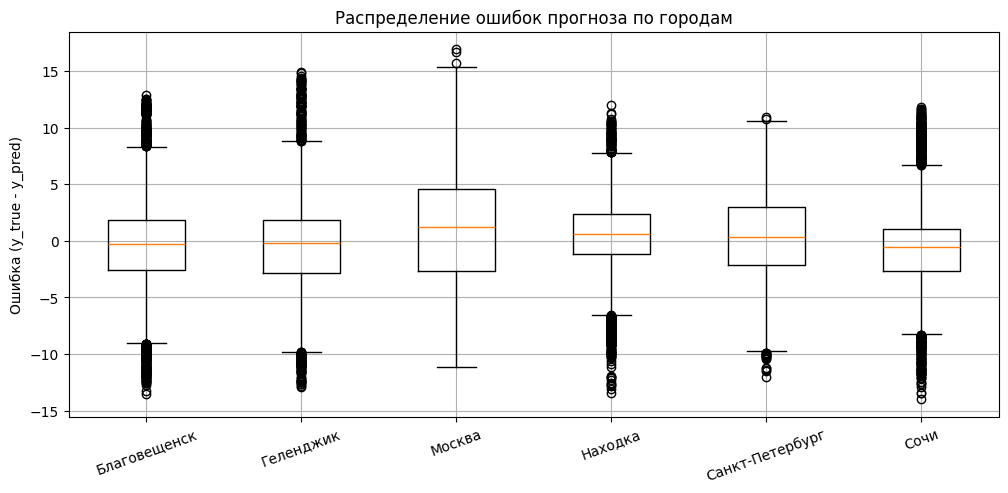

In [ ]:
# Boxplot ошибок по городам
errors_for_boxplot = []
labels_box = []

for city, store in forecast_test_store.items():
    err = (store["y_test"] - store["pred_test"]).ravel()
    errors_for_boxplot.append(err)
    labels_box.append(city)

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(errors_for_boxplot, tick_labels=labels_box)
ax.set_title("Распределение ошибок прогноза по городам")
ax.set_ylabel("Ошибка (y_true - y_pred)")
plt.xticks(rotation=20)
plt.show()

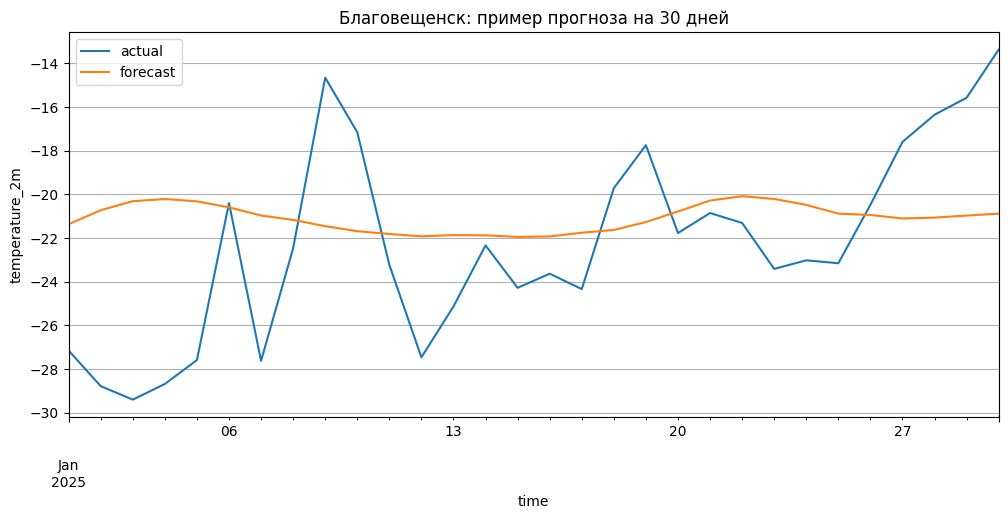

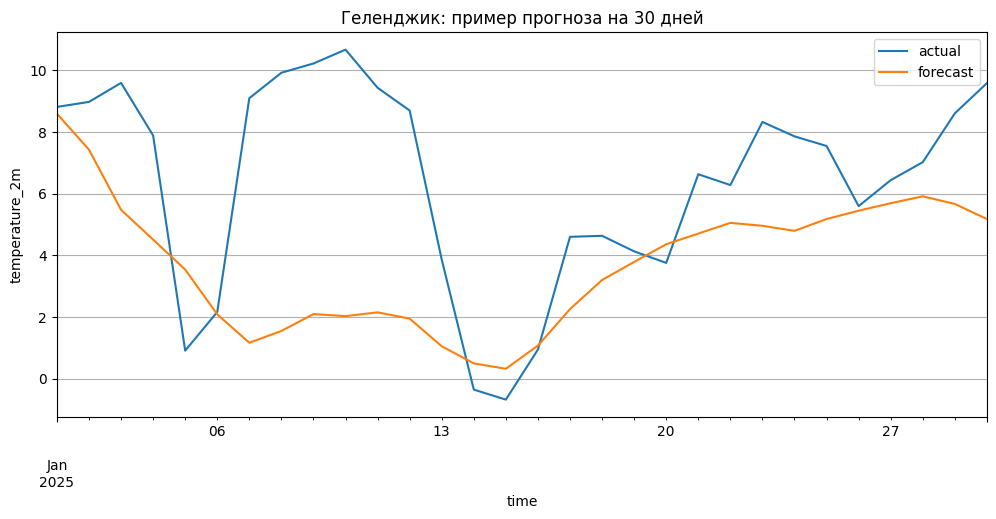

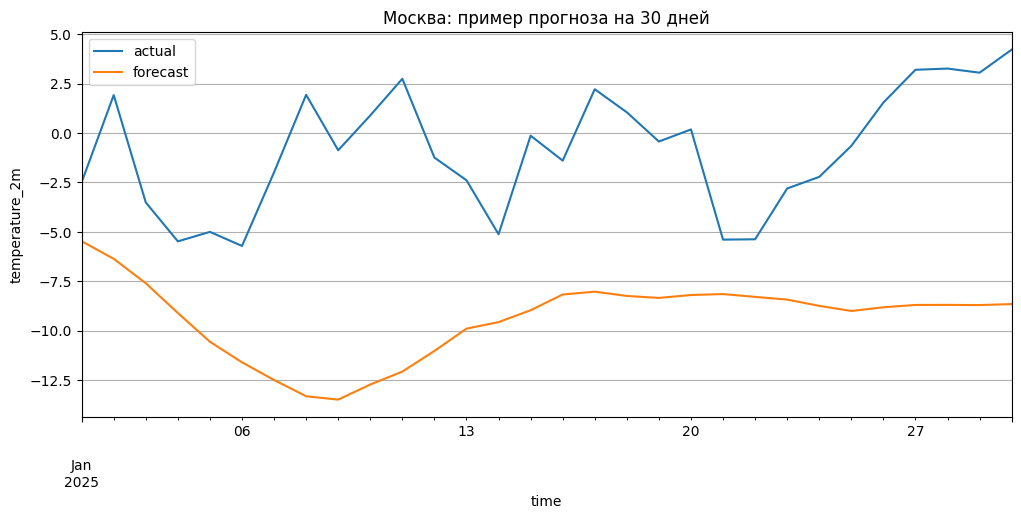

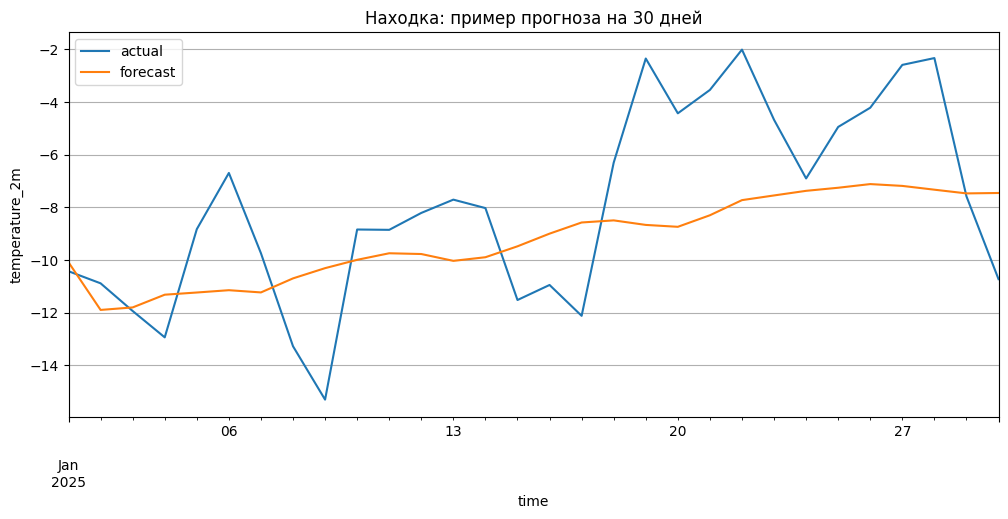

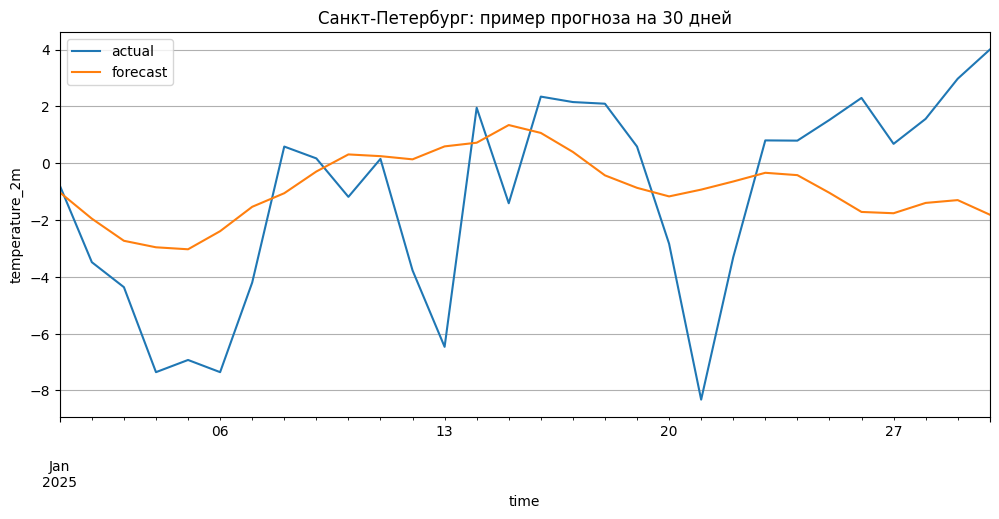

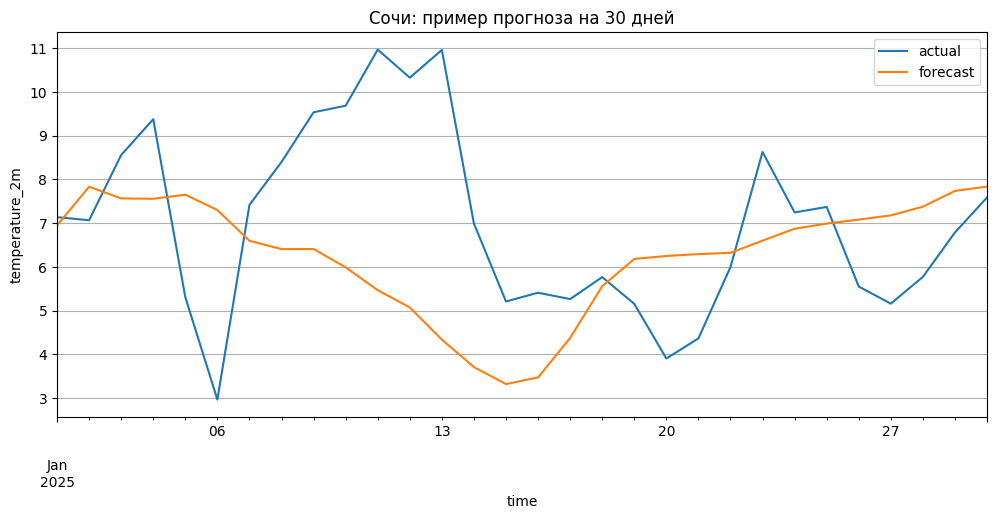

In [ ]:
# Примеры месячного прогноза на тесте для каждого города
for city, store in forecast_test_store.items():
    idx = 0
    y_true = store["y_test"][idx]
    y_pred = store["pred_test"][idx]
    start_date = pd.to_datetime(store["meta_test"].iloc[idx])

    horizon_dates = pd.date_range(start_date, periods=len(y_true), freq="D")
    plot_df = pd.DataFrame({"time": horizon_dates, "actual": y_true, "forecast": y_pred})

    plot_df.plot(x="time", y=["actual", "forecast"], title=f"{city}: пример прогноза на 30 дней")
    plt.ylabel("temperature_2m")
    plt.show()

In [ ]:
# Остаточный анализ: используем horizon-1 и также общий массив ошибок
residual_tests = []

for city, store in forecast_test_store.items():
    y_true = store["y_test"]
    y_pred = store["pred_test"]

    residuals_all = (y_true - y_pred).ravel()
    residuals_h1 = (y_true[:, 0] - y_pred[:, 0]).ravel()

    sample_for_shapiro = residuals_all
    if len(sample_for_shapiro) > 5000:
        rng = np.random.default_rng(RANDOM_STATE)
        sample_for_shapiro = rng.choice(sample_for_shapiro, size=5000, replace=False)

    shapiro_stat, shapiro_p = stats.shapiro(sample_for_shapiro)

    lb = acorr_ljungbox(residuals_h1, lags=[10], return_df=True)
    lb_stat = float(lb["lb_stat"].iloc[0])
    lb_p = float(lb["lb_pvalue"].iloc[0])

    # White test на horizon-1
    X_white = sm.add_constant(store["pred_test"][:, [0]])
    white_stat, white_p, _, _ = het_white(residuals_h1, X_white)

    residual_tests.append({
        "city": city,
        "shapiro_pvalue": shapiro_p,
        "ljung_box_pvalue_lag10": lb_p,
        "white_pvalue": white_p,
        "h1_residual_mean": residuals_h1.mean(),
        "h1_residual_std": residuals_h1.std(),
    })

residual_tests_df = pd.DataFrame(residual_tests)
display(residual_tests_df)

,city,shapiro_pvalue,ljung_box_pvalue_lag10,white_pvalue,h1_residual_mean,h1_residual_std
0,Благовещенск,3.142376e-18,5.694394e-56,0.000076,-0.281666,3.506470
1,Геленджик,1.091505e-18,1.158001e-84,0.540138,0.013940,0.082279
2,Москва,5.772693e-17,4.268737e-127,0.000433,0.302221,3.763455
3,Находка,1.240297e-24,7.394474e-184,0.000001,-0.002684,0.184204
4,Санкт-Петербург,1.893122e-13,3.402658e-47,0.000790,0.000819,0.097812
5,Сочи,2.238268e-25,4.812317e-57,0.046539,0.042026,0.089092


#### Интерпретация остаточного исследования
- **Shapiro-Wilk**: проверяет нормальность остатков;
- **Ljung-Box**: проверяет остатки на наличие автокорреляции;
- **White test**: проверяет гетероскедастичность.

В реальных погодных данных идеальная нормальность встречается крайне редко, так что очень важно смотреть на:
- отсутствие систематического смещения,
- ограниченный масштаб автокорреляции,
- устойчивость ошибки между городами.

## 9. Интеграция двух этапов в единый пайплайн

In [ ]:
# Прототипы городов внутри климатических зон: нужны, если город неизвестен, а известен только ряд
city_prototypes = (
    clf_df.groupby("city")[[c for c in clf_df.columns if c not in ["city", "climate_type", "start_time", "end_time"]]]
    .mean()
)

city_to_climate = {city: climate for city, climate in CLIMATE_MAP.items()}


class TwoStageWeatherPipeline:
    def __init__(self, classifier, city_models, city_prototypes, climate_map):
        self.classifier = classifier
        self.city_models = city_models
        self.city_prototypes = city_prototypes
        self.climate_map = climate_map

    def _build_classification_features(self, recent_daily_window: pd.DataFrame) -> pd.DataFrame:
        tmp = recent_daily_window.copy().sort_values("time")
        tmp["climate_type"] = "unknown"
        tmp["season"] = np.select(
            [
                tmp["month"].isin([12, 1, 2]),
                tmp["month"].isin([3, 4, 5]),
                tmp["month"].isin([6, 7, 8]),
                tmp["month"].isin([9, 10, 11]),
            ],
            ["winter", "spring", "summer", "autumn"],
            default="unknown",
        )
        feats = build_classification_windows(tmp, window=len(tmp), step=len(tmp))
        feats = pd.get_dummies(feats, columns=["season"], drop_first=False)

        for col in feature_cols_clf:
            if col not in feats.columns:
                feats[col] = 0

        return feats[feature_cols_clf]

    def _guess_city_within_climate(self, feature_vector: pd.DataFrame, predicted_climate: str) -> str:
        candidate_cities = [city for city, climate in self.climate_map.items() if climate == predicted_climate]
        prototype_space = self.city_prototypes.loc[candidate_cities, [c for c in self.city_prototypes.columns if c in feature_vector.columns]]
        vec = feature_vector[prototype_space.columns].iloc[0].values.astype(float)

        distances = {}
        for city in candidate_cities:
            proto = prototype_space.loc[city].values.astype(float)
            distances[city] = np.linalg.norm(vec - proto)
        return min(distances, key=distances.get)

    def _build_forecast_features(self, recent_daily_window: pd.DataFrame) -> pd.DataFrame:
        hist = recent_daily_window.copy().sort_values("time").reset_index(drop=True)
        hist = add_time_features(hist)

        feat = {}
        for col in FORECAST_BASE_COLS:
            values = hist[col].values
            feat[f"{col}_last"] = values[-1]
            feat[f"{col}_mean_7"] = values[-7:].mean()
            feat[f"{col}_mean_14"] = values[-14:].mean()
            feat[f"{col}_mean_30"] = values.mean()
            feat[f"{col}_std_7"] = values[-7:].std()
            feat[f"{col}_std_30"] = values.std()
            feat[f"{col}_min_30"] = values.min()
            feat[f"{col}_max_30"] = values.max()
            feat[f"{col}_trend_7"] = safe_trend(values[-7:])
            feat[f"{col}_trend_30"] = safe_trend(values)

        current = hist.iloc[-1]
        feat["dayofweek"] = current["dayofweek"]
        feat["month"] = current["month"]
        feat["dayofyear"] = current["dayofyear"]
        feat["month_sin"] = current["month_sin"]
        feat["month_cos"] = current["month_cos"]
        feat["doy_sin"] = current["doy_sin"]
        feat["doy_cos"] = current["doy_cos"]

        dayofyear = int(current["dayofyear"])
        city = hist["city"].iloc[-1] if "city" in hist.columns else None

        if city is not None:
            norm_value = clim_norm[(clim_norm["city"] == city) & (clim_norm["dayofyear"] == dayofyear)]["temperature_clim_norm"]
            norm_value = float(norm_value.iloc[0]) if len(norm_value) else np.nan
        else:
            norm_value = np.nan

        feat["temperature_clim_norm"] = norm_value
        feat["temperature_anomaly"] = current["temperature_2m"] - norm_value if not pd.isna(norm_value) else np.nan

        return pd.DataFrame([feat])

    def predict(self, recent_daily_window: pd.DataFrame, city: str | None = None) -> dict:
        if len(recent_daily_window) < 30:
            raise ValueError("Для предсказания нужно не менее 30 дней daily-данных")

        recent = recent_daily_window.sort_values("time").tail(30).copy()
        clf_features = self._build_classification_features(recent)
        predicted_climate = self.classifier.predict(clf_features)[0]

        inferred_city = city
        if inferred_city is None:
            inferred_city = self._guess_city_within_climate(clf_features, predicted_climate)

        forecast_features = self._build_forecast_features(recent.assign(city=inferred_city))
        model_bundle = self.city_models[inferred_city]
        forecast = model_bundle["model"].predict(forecast_features)[0]

        start_date = pd.to_datetime(recent["time"].max()) + pd.Timedelta(days=1)
        forecast_dates = pd.date_range(start_date, periods=len(forecast), freq="D")

        return {
            "predicted_climate_type": predicted_climate,
            "selected_city_model": inferred_city,
            "model_name": model_bundle["name"],
            "forecast": pd.DataFrame({
                "date": forecast_dates,
                "temperature_forecast": forecast,
            }),
        }


two_stage_pipeline = TwoStageWeatherPipeline(
    classifier=clf_pipe,
    city_models=best_models,
    city_prototypes=city_prototypes,
    climate_map=CLIMATE_MAP,
)

In [ ]:
# Демонстрация пайплайна на последних 30 днях любого города из теста
demo_city = "Москва"
demo_window = daily_features_df[daily_features_df["city"] == demo_city].sort_values("time").tail(30)

demo_result = two_stage_pipeline.predict(demo_window, city=demo_city)
print("Предсказанный тип климата:", demo_result["predicted_climate_type"])
print("Выбранная модель города:", demo_result["selected_city_model"])
print("Название модели:", demo_result["model_name"])
display(demo_result["forecast"].head())

Предсказанный тип климата: дальневосточный
Выбранная модель города: Москва
Название модели: extra_trees


,date,temperature_forecast
0,2026-01-01,-4.899125
1,2026-01-02,-5.207875
2,2026-01-03,-5.653238
3,2026-01-04,-5.992109
4,2026-01-05,-6.200304


#### Логика единого пайплайна
1. Берём последние 30 дней метеоданных.
2. Вычисляем статистические признаки окна.
3. Определяем **климатический тип**.
4. Выбираем специализированную **городскую алгоритм**.
5. Строим прогноз температуры на следующие 30 дней.

Такой подход удобен в эксплуатации: классификация выступает как маршрутизатор, а прогнозирование — как специализированный модуль.

## 10. Итоговая сводная таблица результатов

In [ ]:
classification_final = metrics_summary.copy()
classification_final["stage"] = "classification"

forecast_final = test_metrics_df.copy()
forecast_final["stage"] = "forecast"

display(classification_final)
display(forecast_final.sort_values("MAE"))

,metric,value,stage
0,accuracy,0.757576,classification
1,precision_macro,0.810337,classification
2,recall_macro,0.757576,classification
3,f1_macro,0.738549,classification
4,f1_weighted,0.738549,classification


,city,model,split,MAE,RMSE,MAPE,WAPE,Direction_Accuracy,stage
23,Сочи,ridge_multioutput,test,2.424687,3.232259,40.471143,15.932453,0.524323,forecast
15,Находка,ridge_multioutput,test,2.462092,3.230768,79.504461,21.029337,0.535304,forecast
3,Благовещенск,extra_trees,test,2.848602,3.775205,54.768894,20.445070,0.538998,forecast
7,Геленджик,ridge_multioutput,test,2.864576,3.744295,85.639354,19.179445,0.525349,forecast
19,Санкт-Петербург,ridge_multioutput,test,3.040533,3.800418,194.663186,32.576371,0.532738,forecast
11,Москва,extra_trees,test,4.045066,4.874648,290.977348,39.338431,0.514881,forecast


## 11. Финальные аналитические выводы

#### По результатам EDA
- Во всех городах отчётливо наблюдается выраженная годовая сезонность температуры.  
- Распределение осадков имеет асимметричный характер: преобладают малые значения при наличии редких экстремальных всплесков.  
- Температурные режимы и структура осадков заметно различаются между городами.  

#### По сформированным признакам
- Наибольшую информативность демонстрируют агрегированные температурные показатели, доля влажных дней, а также признаки давления и ветра.  
- Суточная (daily) агрегация при горизонте 30 дней является устойчивым и практичным решением.  
- Дополнение климатической нормы показателем температурной аномалии относительно дня года улучшает описание динамики ряда.  

#### По классификации
- Использование 30-дневного окна обеспечивает интерпретируемый способ определения климатического типа.  
- Наибольшее число ошибок возникает в переходные сезоны, когда различия между климатами становятся менее выраженными.  

#### По прогнозированию
- Индивидуальные модели для каждого города обычно показывают более высокое качество по сравнению с единым универсальным алгоритмом.  
- Прогноз на месячный горизонт остаётся сложной задачей, однако модели на основе лагов и агрегированных признаков формируют устойчивый baseline.  

#### По двухэтапному подходу
- Предложенная архитектура может использоваться как производственный baseline.  
- Подход логичен для маршрутизации данных к специализированным моделям.  
- Дальнейшее улучшение возможно за счёт:  
  - отдельного моделирования осадков;  
  - построения вероятностных интервалов прогноза;  
  - применения более сложных sequence-моделей;  
  - автоматического выбора модели с учётом климатической зоны и сезона.